# fig1_new_region - Part 5/8\n\n自动拆分版本（按步骤执行）。\n包含统一 bootstrap 和共享模块导入。\n

In [ ]:
# AUTO_BOOTSTRAP_V2
from pathlib import Path
import sys
import os
import builtins
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "projects").exists():
    cur = Path.cwd().resolve()
    for p in [cur] + list(cur.parents):
        if (p / "projects").exists():
            ROOT = p
            break

NB_PATH = Path.cwd()
if "clone_motif" in str(NB_PATH):
    PROJECT_DIR = ROOT / "projects" / "clone_motif"
else:
    PROJECT_DIR = ROOT / "projects" / "our_multiregion_motif"

DATA_RAW = PROJECT_DIR / "data" / "raw"
DATA_PROCESSED = PROJECT_DIR / "data" / "processed"
OUT_FIG = PROJECT_DIR / "outputs" / "figures"
OUT_TABLE = PROJECT_DIR / "outputs" / "tables"
OUT_ARCH = PROJECT_DIR / "outputs" / "archives"

for d in [DATA_PROCESSED, OUT_FIG, OUT_TABLE, OUT_ARCH]:
    d.mkdir(parents=True, exist_ok=True)

SHARED_SRC = ROOT / "projects" / "shared" / "src"
if str(SHARED_SRC) not in sys.path:
    sys.path.append(str(SHARED_SRC))

from motif_common import combination, indices_for_region, union_indices_for_regions, p_to_star, format_p_decimal_3sig, sort_by_order, truncate_colormap

READ_EXT = {".csv", ".json", ".npy", ".pkl", ".xlsx"}
FIG_EXT = {".svg", ".png", ".pdf"}
TABLE_EXT = {".csv", ".xlsx"}


def _as_path(x):
    return Path(x) if isinstance(x, (str, os.PathLike)) else x


def resolve_read_path(path):
    p = _as_path(path)
    if not isinstance(p, Path):
        return path
    if p.is_absolute() or p.exists():
        return str(p)
    if p.suffix.lower() in READ_EXT:
        for c in [DATA_RAW / p.name, ROOT / p.name]:
            if c.exists():
                return str(c)
    return str(p)


def resolve_write_path(path):
    p = _as_path(path)
    if not isinstance(p, Path):
        return path
    if p.is_absolute():
        p.parent.mkdir(parents=True, exist_ok=True)
        return str(p)
    ext = p.suffix.lower()
    if ext in FIG_EXT:
        out = OUT_FIG / p.name
    elif ext in TABLE_EXT:
        out = OUT_TABLE / p.name
    elif ext == ".zip":
        out = OUT_ARCH / p.name
    elif ext == ".npy":
        out = DATA_PROCESSED / p.name
    else:
        out = PROJECT_DIR / p
    out.parent.mkdir(parents=True, exist_ok=True)
    return str(out)

if not hasattr(builtins, "_orig_open_codex"):
    builtins._orig_open_codex = builtins.open


def _open_patch(file, mode="r", *args, **kwargs):
    if isinstance(file, (str, os.PathLike)):
        if any(m in mode for m in ["r", "a"]):
            file = resolve_read_path(file)
        if any(m in mode for m in ["w", "a", "x"]):
            file = resolve_write_path(file)
    return builtins._orig_open_codex(file, mode, *args, **kwargs)


builtins.open = _open_patch

if not hasattr(np, "_orig_load_codex"):
    np._orig_load_codex = np.load
np.load = lambda file, *a, **k: np._orig_load_codex(resolve_read_path(file), *a, **k)

if not hasattr(np, "_orig_save_codex"):
    np._orig_save_codex = np.save
np.save = lambda file, arr, *a, **k: np._orig_save_codex(resolve_write_path(file), arr, *a, **k)

if not hasattr(pd, "_orig_read_csv_codex"):
    pd._orig_read_csv_codex = pd.read_csv
pd.read_csv = lambda f, *a, **k: pd._orig_read_csv_codex(resolve_read_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)

if not hasattr(pd, "_orig_read_excel_codex"):
    pd._orig_read_excel_codex = pd.read_excel
pd.read_excel = lambda f, *a, **k: pd._orig_read_excel_codex(resolve_read_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)

if not hasattr(pd.DataFrame, "_orig_to_csv_codex"):
    pd.DataFrame._orig_to_csv_codex = pd.DataFrame.to_csv


def _to_csv_patch(self, path_or_buf=None, *args, **kwargs):
    if isinstance(path_or_buf, (str, os.PathLike)):
        path_or_buf = resolve_write_path(path_or_buf)
    return pd.DataFrame._orig_to_csv_codex(self, path_or_buf, *args, **kwargs)


pd.DataFrame.to_csv = _to_csv_patch

if not hasattr(pd.DataFrame, "_orig_to_excel_codex"):
    pd.DataFrame._orig_to_excel_codex = pd.DataFrame.to_excel


def _to_excel_patch(self, excel_writer, *args, **kwargs):
    if isinstance(excel_writer, (str, os.PathLike)):
        excel_writer = resolve_write_path(excel_writer)
    return pd.DataFrame._orig_to_excel_codex(self, excel_writer, *args, **kwargs)


pd.DataFrame.to_excel = _to_excel_patch

try:
    import matplotlib.pyplot as plt
    if not hasattr(plt, "_orig_savefig_codex"):
        plt._orig_savefig_codex = plt.savefig
    plt.savefig = lambda f, *a, **k: plt._orig_savefig_codex(resolve_write_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)
except Exception:
    pass

print(f"[bootstrap] project={PROJECT_DIR.name} data={DATA_RAW}")


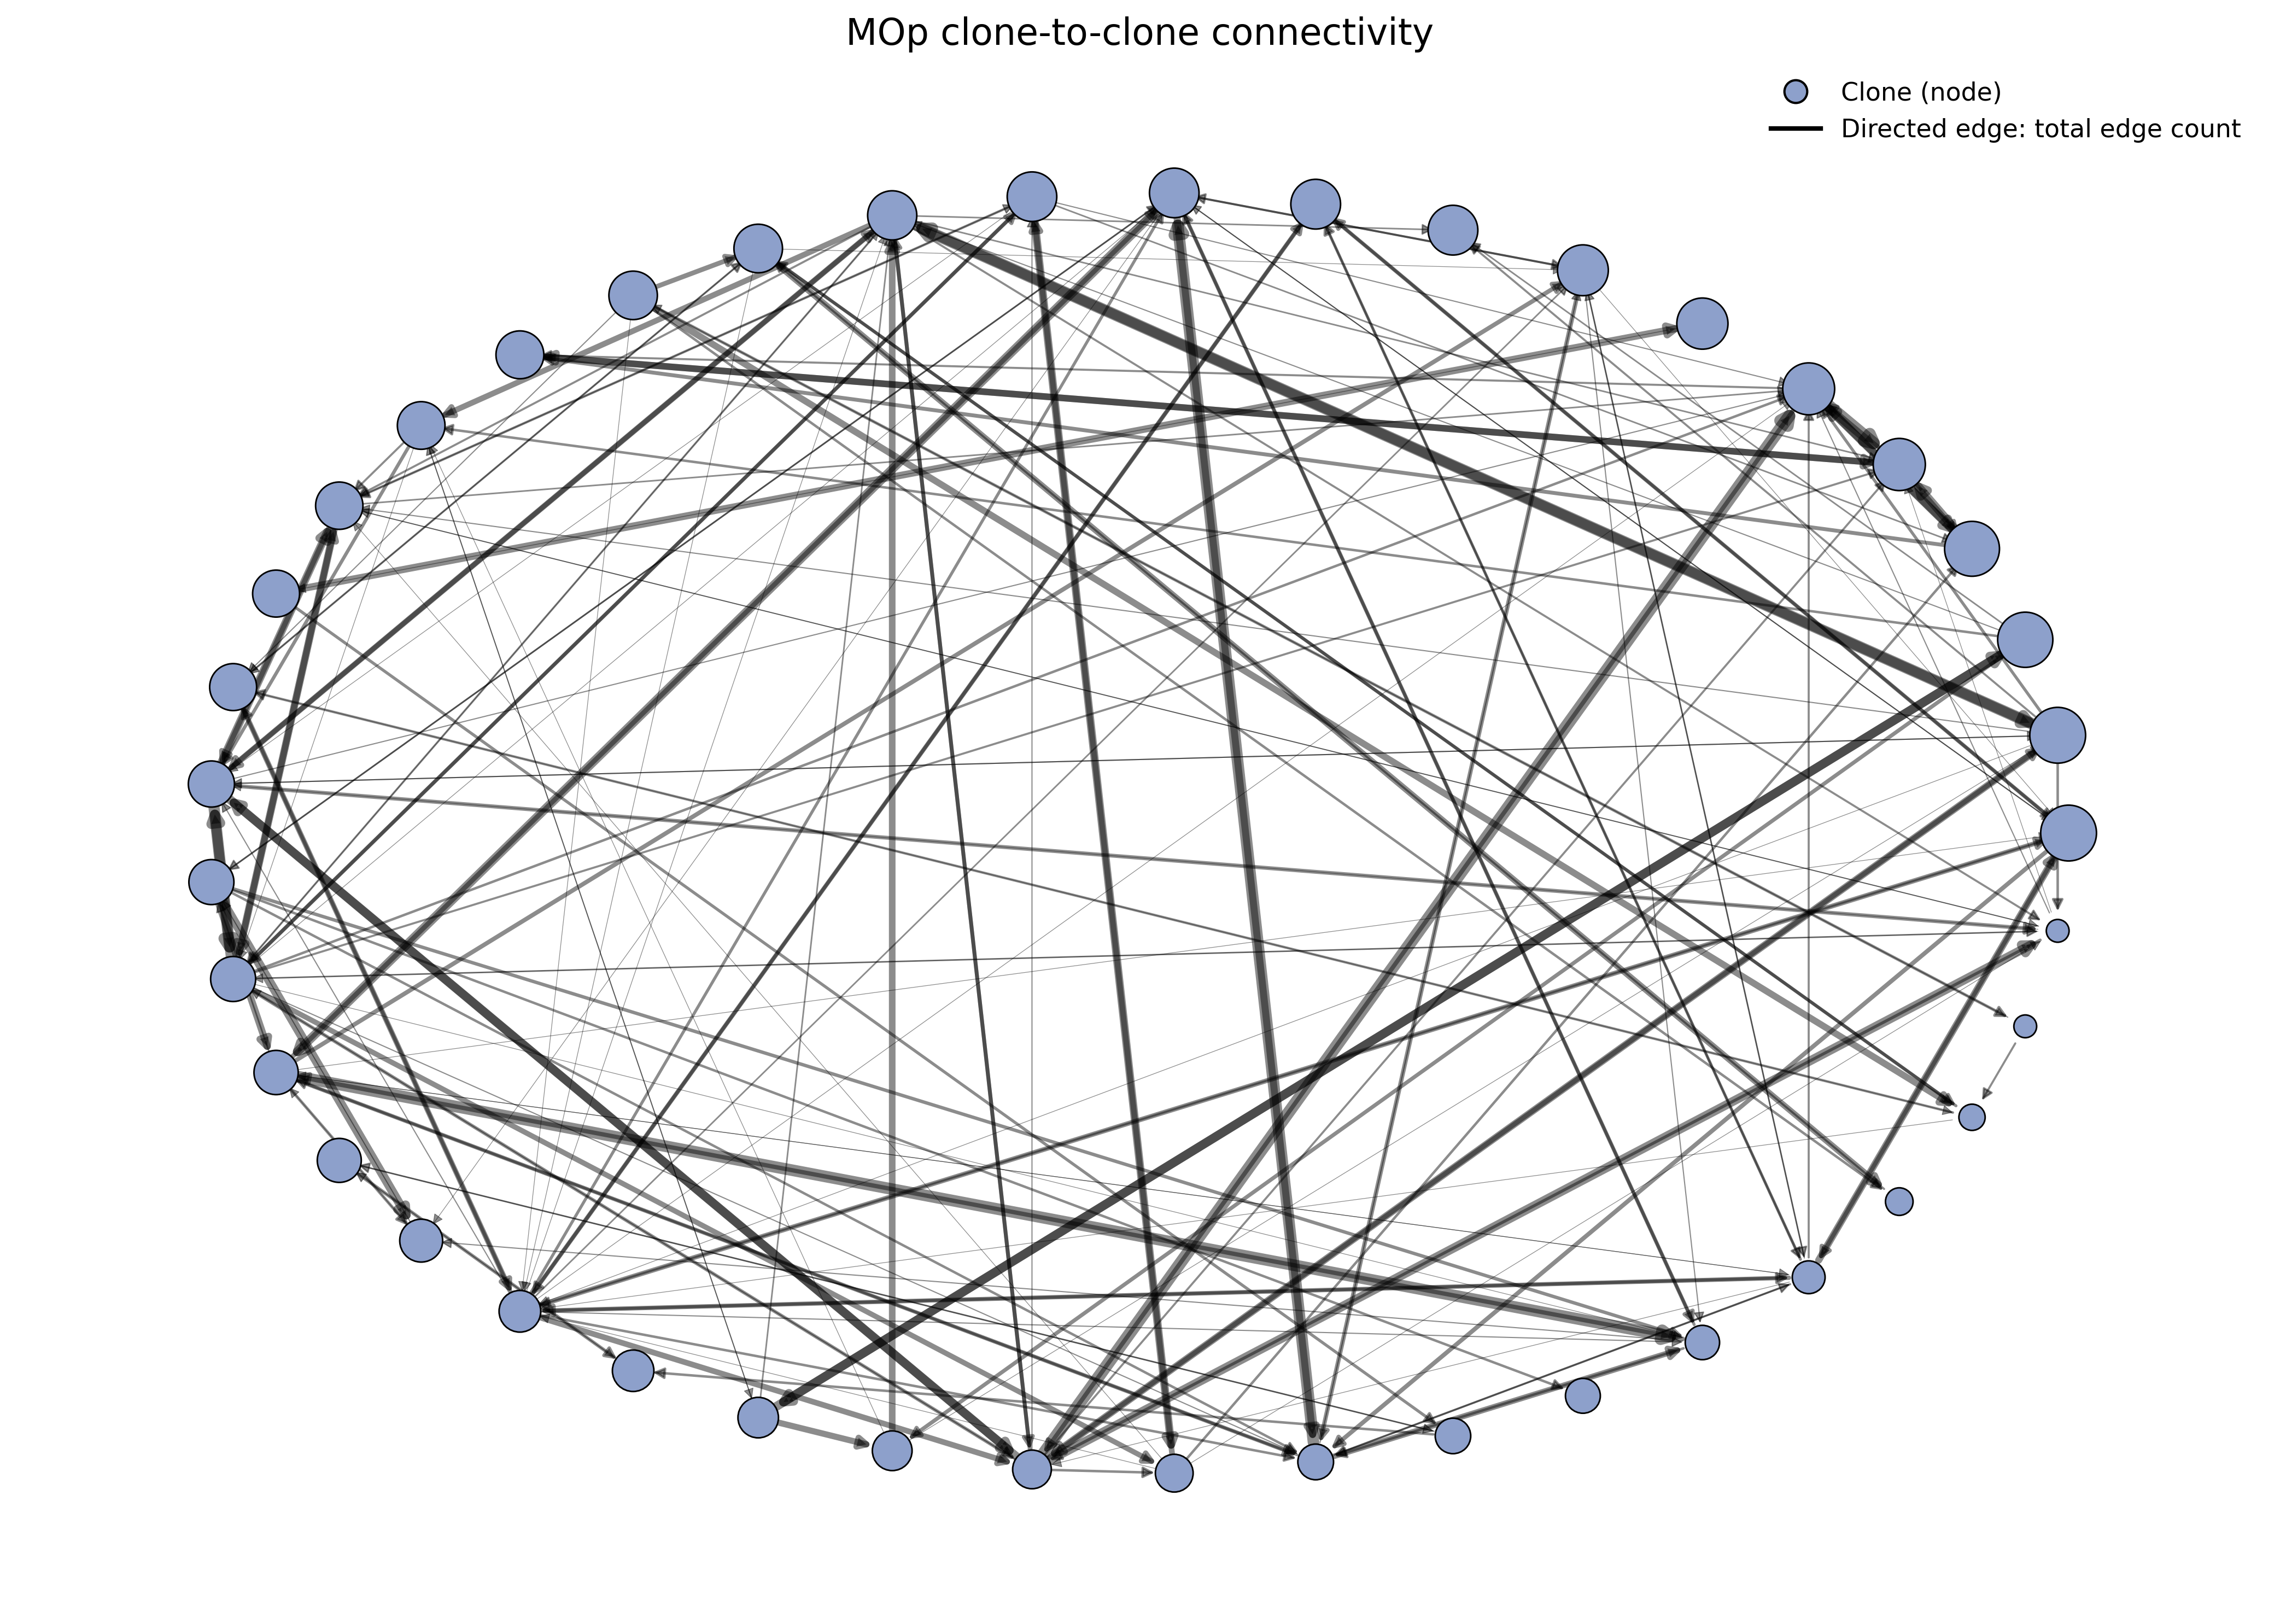

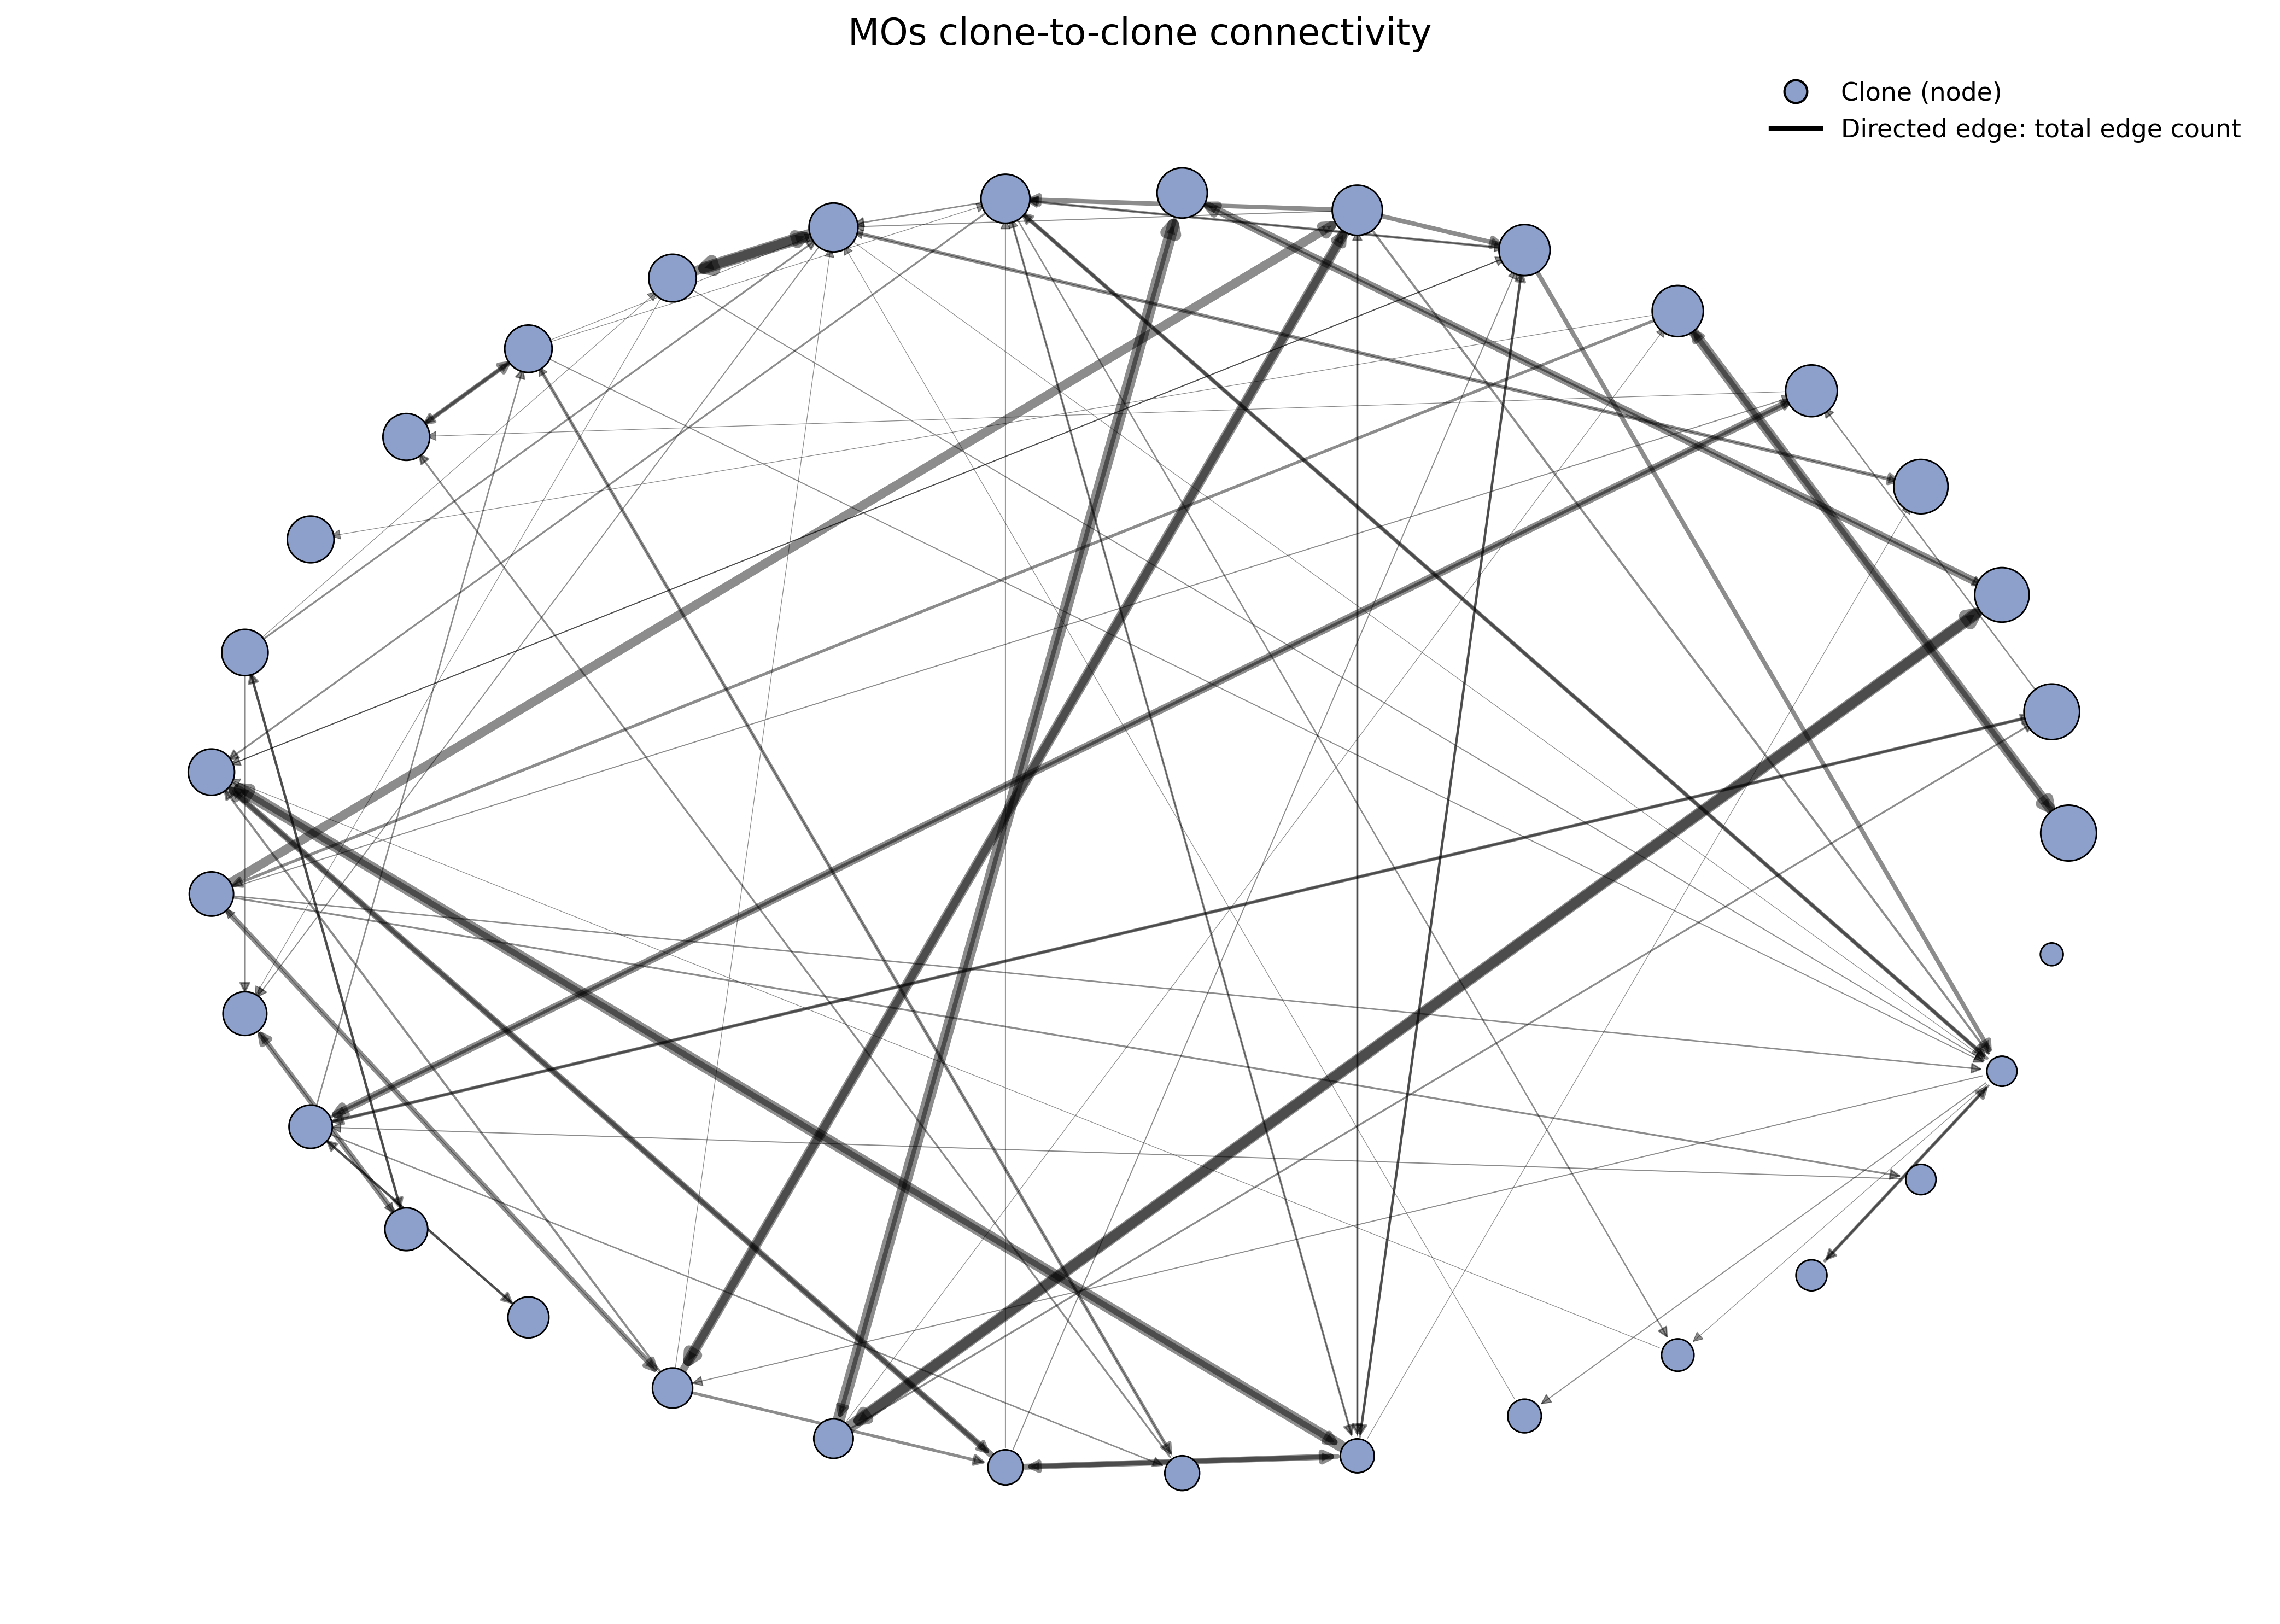

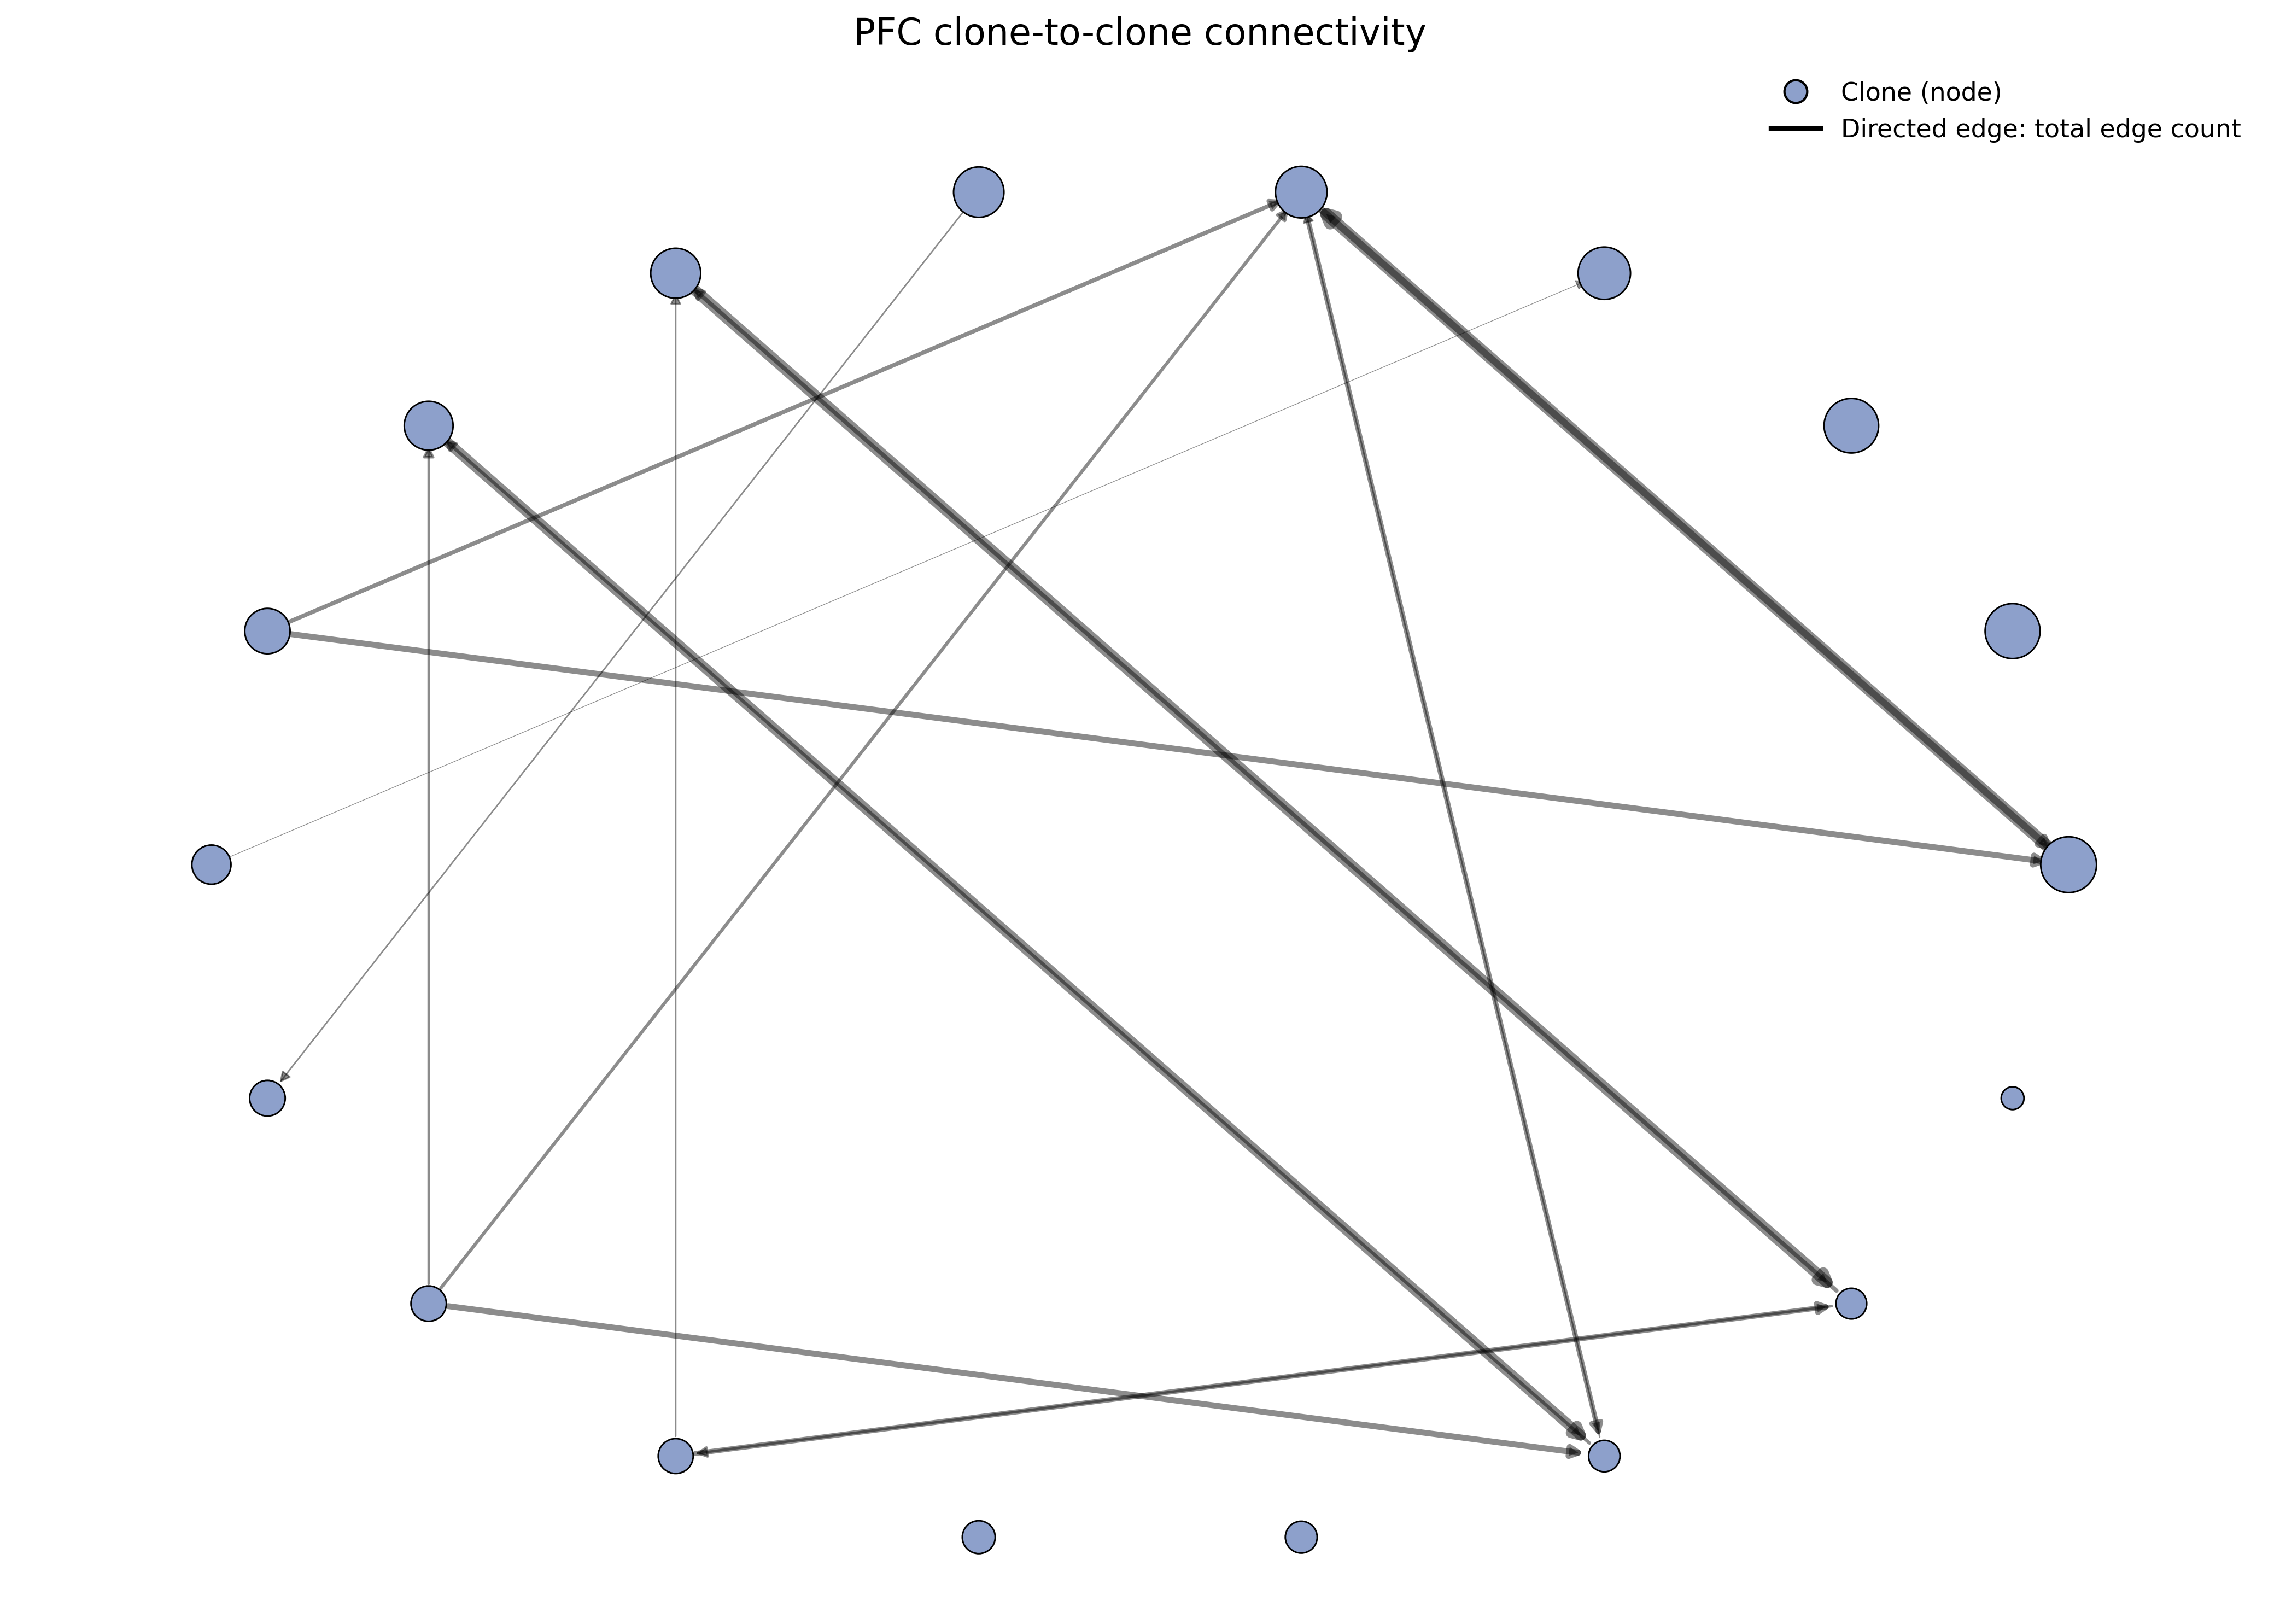

✅ Done.


In [49]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ============================================================
# 输入：你需要已经有 sc, names, df
#   sc   : N×N numpy
#   names: 长度 N 的 neuron id 列表/数组
#   df   : metadata，至少含 clone / Layer / Clone_region / (name or Unnamed:0)
# 输出：3 张图（MOp / MOs / PFC） clone-level 有向加权图
#   - 节点=clone；环形排序
#   - 节点大小~内部连接概率 p_in=e_in/(n(n-1))，并限制在 [s_min, s_max]
#   - 边粗细~clone间连接数 weight；边上标 weight（可设阈值）
#   - 不显示节点名字
# ============================================================

# ===================== 0) 字段识别 + 预处理 =====================
names = [str(x) for x in names]
name_to_idx = {nid: i for i, nid in enumerate(names)}

# neuron id 列
if "name" in df.columns:
    neuron_id_col = "name"
elif "Unnamed: 0" in df.columns:
    neuron_id_col = "Unnamed: 0"
else:
    raise ValueError("df 里找不到 neuron id 列（name / Unnamed: 0）")

# 必需列
need = {"clone", "Layer"}
miss = need - set(df.columns)
if miss:
    raise ValueError(f"df 缺少列: {miss}")

# Clone_region 列
clone_region_col = None
for cand in ["Clone_region", "clone_region", "CLONE_REGION"]:
    if cand in df.columns:
        clone_region_col = cand
        break
if clone_region_col is None:
    raise ValueError("df 里找不到 Clone_region 列（Clone_region/clone_region/CLONE_REGION）")

df2 = df.copy()
df2[neuron_id_col] = df2[neuron_id_col].astype(str)
df2[clone_region_col] = df2[clone_region_col].astype(str)

# ===================== 1) 三大脑区：MOp/MOs/其它=PFC =====================
def group3(r):
    r = str(r)
    if r.startswith("MOp"): return "MOp"
    if r.startswith("MOs"): return "MOs"
    return "PFC"

df2["group3"] = df2[clone_region_col].map(group3)

# clone -> group（按 clone 内神经元投票）
clone_to_group = (df2.groupby("clone")["group3"]
                  .agg(lambda x: x.value_counts().index[0])
                  .to_dict())

# clone -> neuron indices（映射到 sc/names）
clone_to_indices = {}
for cl, sub in df2.groupby("clone"):
    ids = sub[neuron_id_col].tolist()
    idxs = [name_to_idx[i] for i in ids if i in name_to_idx]
    idxs = sorted(set(idxs))
    if len(idxs) >= 2:  # 至少2个点才有内部边
        clone_to_indices[cl] = np.asarray(idxs, dtype=int)

# ===================== 2) 参数（按需调） =====================
edge_thr = 0.0           # 神经元层面：sc > edge_thr 视为边
min_weight = 5           # clone->clone 边最小权重
top_edges = None         # 太乱可设 300/500；不限制就 None
label_edges = True       # 边上标 weight 数字
edge_label_min = 10      # 只给权重>=这个的边标数字

# 节点大小范围（强制控制）
s_min = 100
s_max = 600
node_gamma = 0.7         # 0.5~1.0 越小差异越温和
ring_order = "p_in_desc" # "p_in_desc" / "p_in_asc" / "name"

# 标题字号统一
TITLE_FONTSIZE = 16

# ===================== 3) 构图：每个脑区内部 clone 图 =====================
def build_graph_for_group(group_name):
    clones = [cl for cl, g in clone_to_group.items()
              if g == group_name and cl in clone_to_indices]
    clones = sorted(clones, key=lambda x: str(x))
    if len(clones) == 0:
        return None

    G = nx.DiGraph()
    idx_arrays = {cl: clone_to_indices[cl] for cl in clones}

    # 节点属性：n, e_in, p_in
    for cl in clones:
        idx = idx_arrays[cl]
        n = len(idx)
        block = sc[np.ix_(idx, idx)]
        B = (block > edge_thr).astype(np.uint8)
        np.fill_diagonal(B, 0)
        e_in = int(B.sum())
        denom = n * (n - 1)
        p_in = (e_in / denom) if denom > 0 else 0.0
        G.add_node(cl, n=n, e_in=e_in, p_in=p_in)

    # 边：clone A -> clone B 的连接数（神经元边数）
    edges = []
    for ca in clones:
        ia = idx_arrays[ca]
        for cb in clones:
            if ca == cb:
                continue
            ib = idx_arrays[cb]
            w = int(np.count_nonzero(sc[np.ix_(ia, ib)] > edge_thr))
            if w >= min_weight:
                edges.append((ca, cb, w))

    if top_edges is not None and len(edges) > top_edges:
        edges = sorted(edges, key=lambda x: x[2], reverse=True)[:top_edges]

    for ca, cb, w in edges:
        G.add_edge(ca, cb, weight=w)

    return G

# ===================== 4) 画图：环形布局 + 节点大小范围控制 + legend =====================
def plot_clone_graph_ring(G, title):
    nodes = list(G.nodes())

    # ---- 环形排序 ----
    if ring_order == "p_in_desc":
        nodes_sorted = sorted(nodes, key=lambda n: G.nodes[n].get("p_in", 0.0), reverse=True)
    elif ring_order == "p_in_asc":
        nodes_sorted = sorted(nodes, key=lambda n: G.nodes[n].get("p_in", 0.0))
    else:
        nodes_sorted = sorted(nodes, key=lambda n: str(n))

    pos = nx.circular_layout(nodes_sorted)

    # ---- 节点大小：p_in -> [s_min, s_max] ----
    p_in = np.array([G.nodes[n].get("p_in", 0.0) for n in nodes_sorted], float)
    if p_in.max() > p_in.min():
        pn = (p_in - p_in.min()) / (p_in.max() - p_in.min() + 1e-12)
    else:
        pn = np.zeros_like(p_in)
    node_sizes = s_min + (s_max - s_min) * (pn ** node_gamma)

    plt.figure(figsize=(14, 10))
    ax = plt.gca()
    ax.set_axis_off()

    # 节点（圈=clone）
    node_color = "#8da0cb"
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=nodes_sorted,
        node_size=node_sizes,
        node_color=node_color,
        edgecolors="black",
        linewidths=0.7,
        ax=ax
    )

    # 边（有向边=total edge count）
    edgelist = list(G.edges())
    if edgelist:
        wts = np.array([G[u][v]["weight"] for u, v in edgelist], float)
        widths = 0.3 + 5.0 * (wts - wts.min()) / (wts.max() - wts.min() + 1e-12)

        nx.draw_networkx_edges(
            G, pos,
            edgelist=edgelist,
            width=widths,
            arrows=True,
            arrowsize=10,
            alpha=0.45,
            ax=ax
        )

        # if label_edges:
        #     show_edges = [(u, v) for (u, v) in edgelist if G[u][v]["weight"] >= edge_label_min]
        #     edge_labels = {(u, v): str(G[u][v]["weight"]) for (u, v) in show_edges}
        #     nx.draw_networkx_edge_labels(
        #         G, pos,
        #         edge_labels=edge_labels,
        #         font_size=7,
        #         rotate=False,
        #         ax=ax
        #     )

    # ---- 标题：简单英文，统一字号 ----
    ax.set_title(title, fontsize=TITLE_FONTSIZE)

    # ---- legend（圈=clone；有向边=total edge count）----
    legend_handles = [
        Line2D([0], [0], marker='o', color='none',
               markerfacecolor=node_color, markeredgecolor='black',
               markersize=10, label='Clone (node)'),
        Line2D([0], [0], color='black', lw=2,
               label='Directed edge: total edge count'),
    ]
    ax.legend(handles=legend_handles, frameon=False, loc="upper right", fontsize=11)

    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.svg", dpi=300, format="svg", bbox_inches="tight")
    plt.show()

# ===================== 5) 依次画 MOp / MOs / PFC =====================
for region in ["MOp", "MOs", "PFC"]:
    G = build_graph_for_group(region)
    if G is None:
        print(f"[SKIP] {region}: 没有 clone 或不足以建图")
        continue

    # 你要的：脑区 + clone 间连接（英文），简单标题
    title = f"{region} clone-to-clone connectivity"

    plot_clone_graph_ring(G, title)

print("✅ Done.")

[OK] MOp: clones=41, edges=461, edge_density=0.2811, mean_w=5.64
[OK] MOs: clones=33, edges=274, edge_density=0.2595, mean_w=5.29
[OK] PFC: clones=18, edges=67, edge_density=0.2190, mean_w=3.94

=== region_summary_df ===
  region  n_clones  n_edges  edge_density  mean_edge_weight
0    MOp        41      461      0.281098          5.642082
1    MOs        33      274      0.259470          5.288321
2    PFC        18       67      0.218954          3.940299


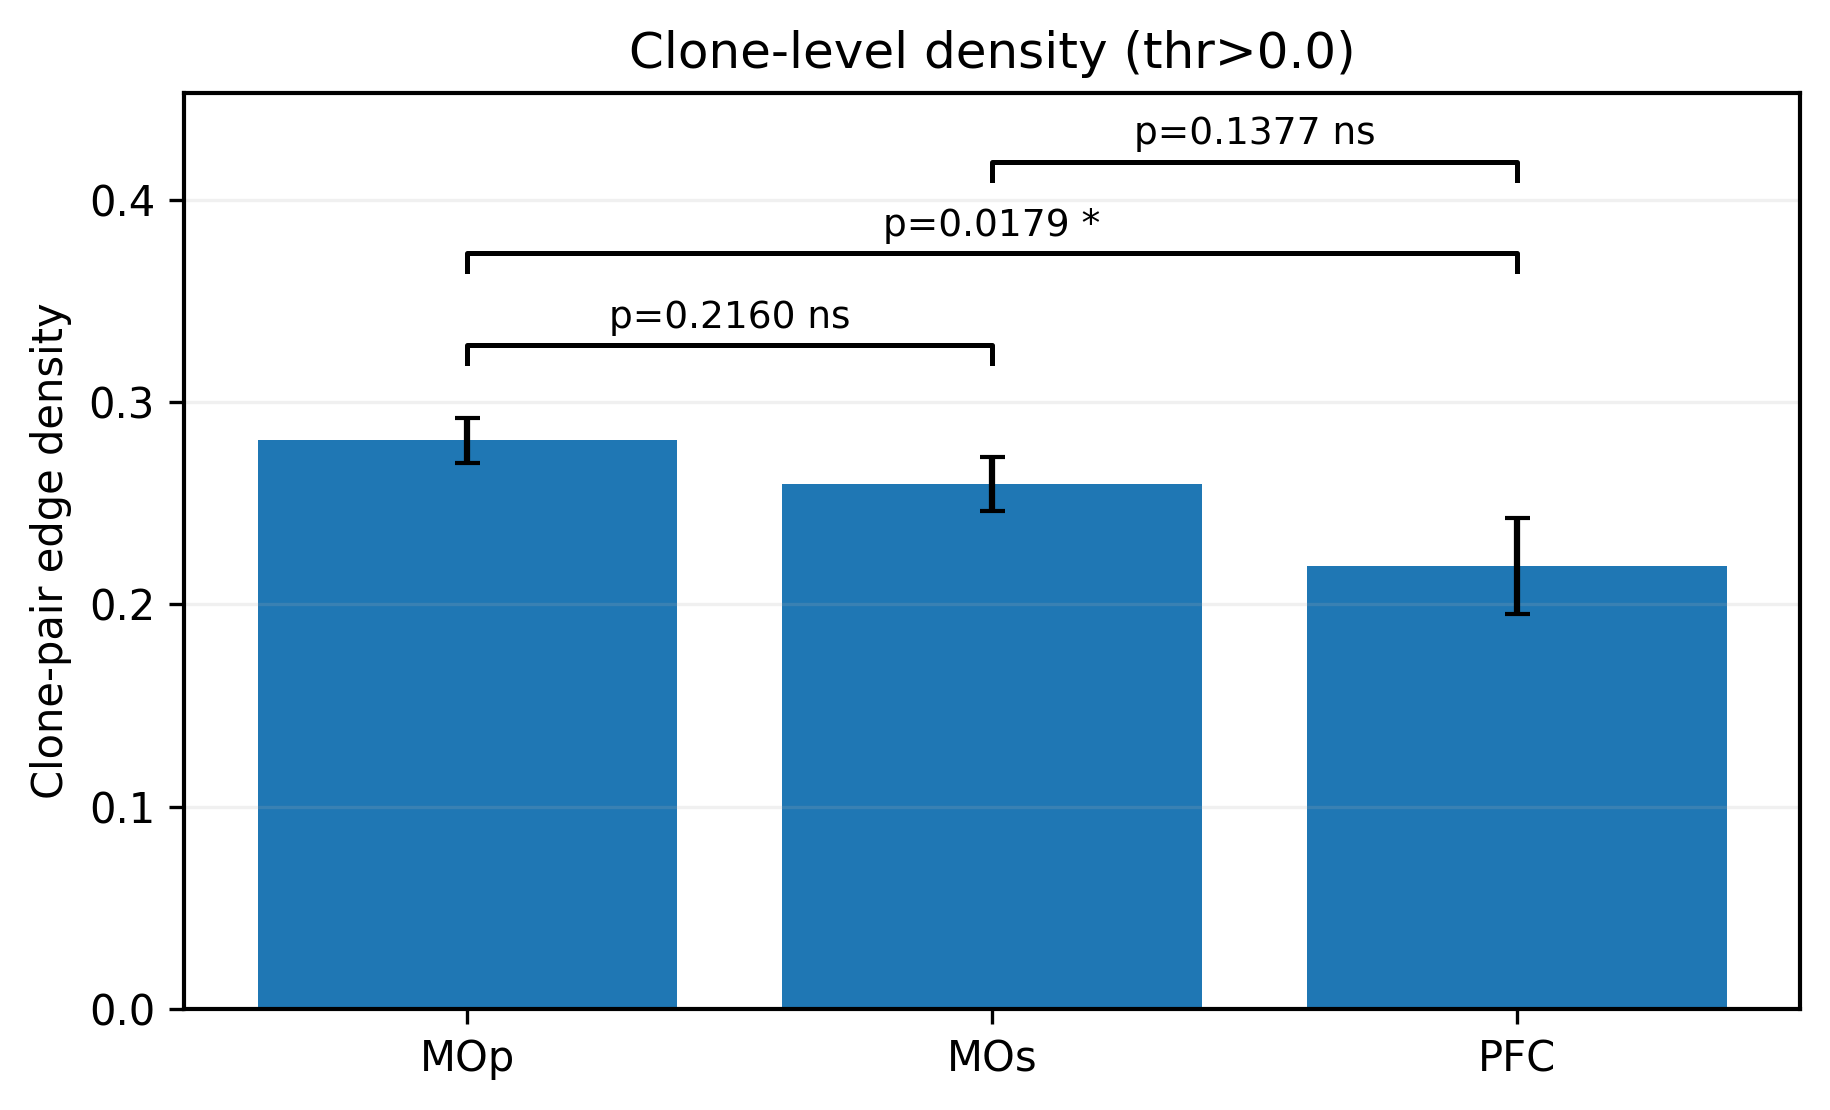

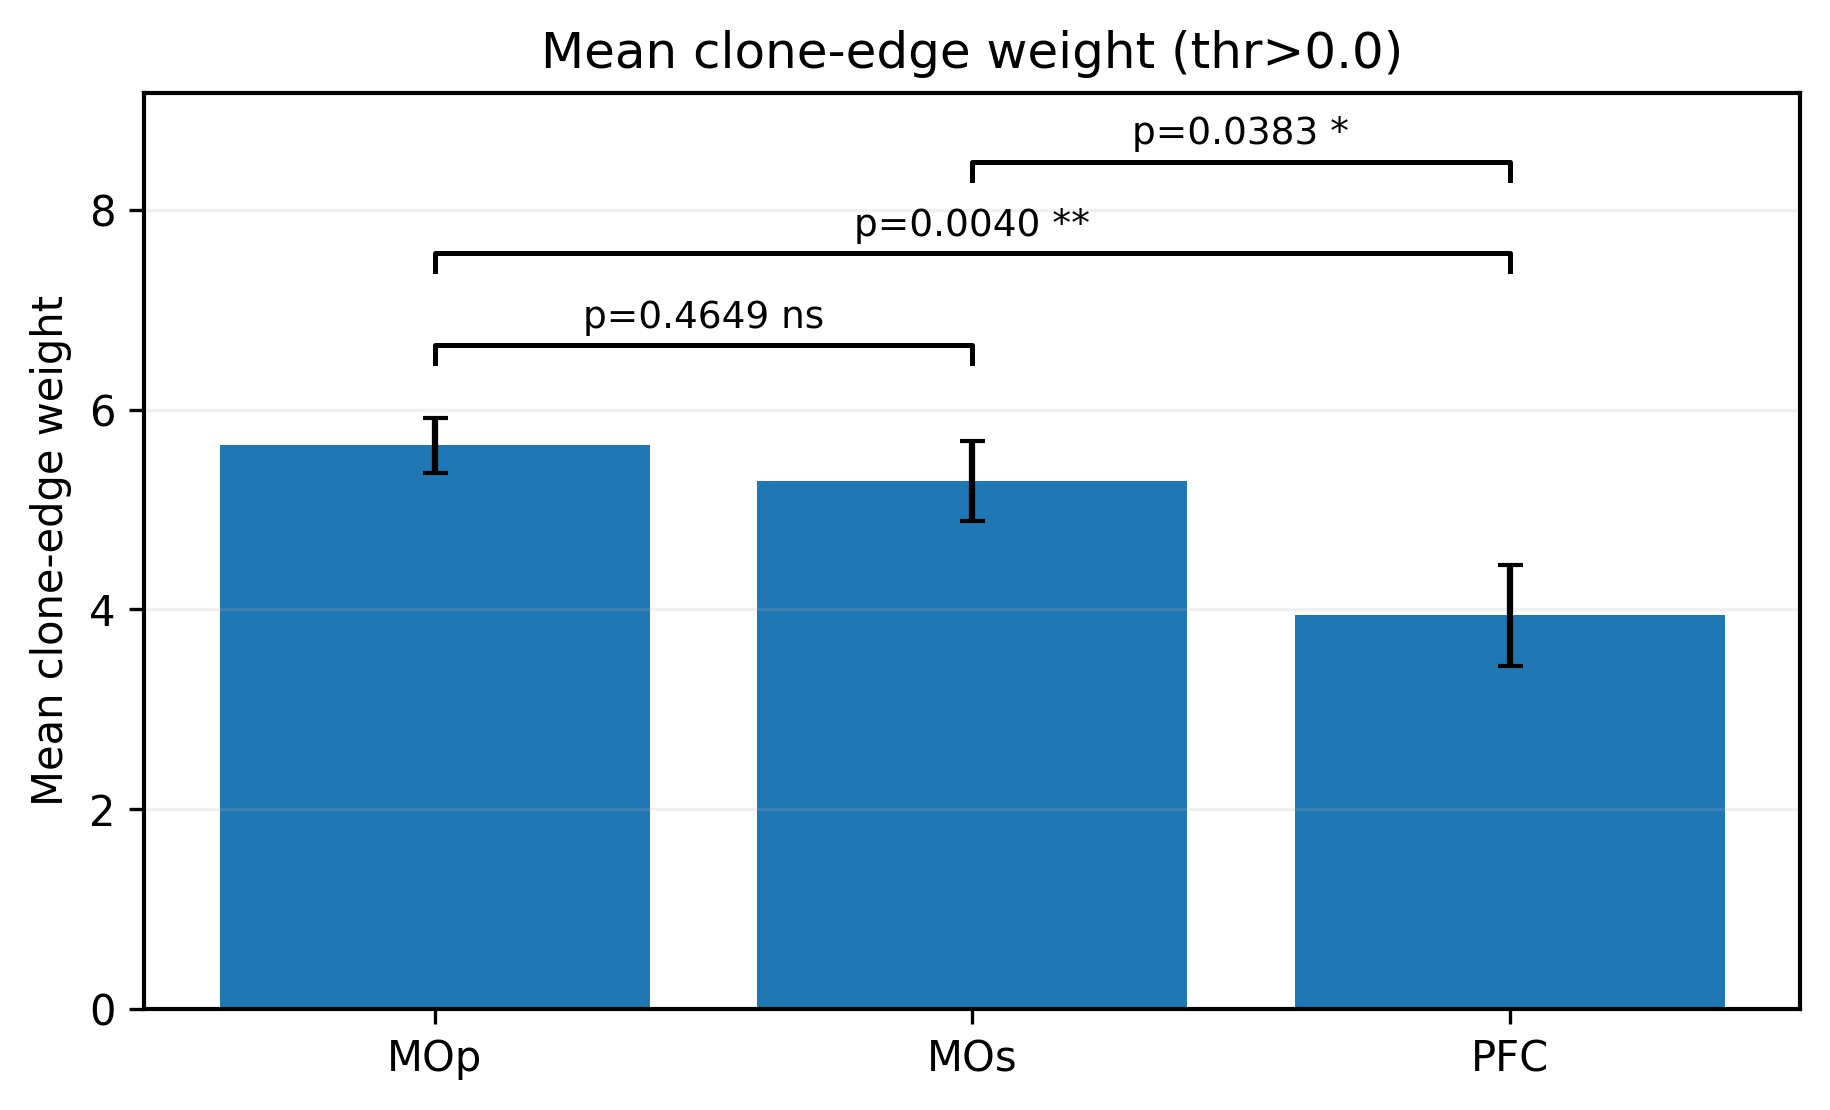

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# ===================== 0) 参数 =====================
edge_thr = 0.0     # neuron-level：sc > edge_thr 视为一条边（可改成 0.05/0.1 等）
min_n = 3          # 每个 clone 至少多少神经元才纳入
regions = ["MOp", "MOs", "PFC"]

# ===================== 1) 字段识别 =====================
names = [str(x) for x in names]
name_to_idx = {nid: i for i, nid in enumerate(names)}

if "name" in df.columns:
    neuron_id_col = "name"
elif "Unnamed: 0" in df.columns:
    neuron_id_col = "Unnamed: 0"
else:
    raise ValueError("df 里找不到 neuron id 列（name / Unnamed: 0）")

if "clone" not in df.columns:
    raise ValueError("df 缺少 clone 列")

clone_region_col = None
for cand in ["Clone_region", "clone_region", "CLONE_REGION"]:
    if cand in df.columns:
        clone_region_col = cand
        break
if clone_region_col is None:
    raise ValueError("df 里找不到 Clone_region 列（Clone_region/clone_region/CLONE_REGION）")

df2 = df.copy()
df2[neuron_id_col] = df2[neuron_id_col].astype(str)
df2[clone_region_col] = df2[clone_region_col].astype(str)

# ===================== 2) 三大脑区：MOp/MOs/其他=PFC =====================
def group3(r):
    r = str(r)
    if r.startswith("MOp"): return "MOp"
    if r.startswith("MOs"): return "MOs"
    return "PFC"

df2["group3"] = df2[clone_region_col].map(group3)

# ===================== 3) 构建 neuron -> clone / group 映射（对齐到 sc/names）=====================
df2 = df2[df2[neuron_id_col].isin(name_to_idx)].copy()
df2["idx"] = df2[neuron_id_col].map(name_to_idx)

idx_to_clone = df2.set_index("idx")["clone"].to_dict()
idx_to_group = df2.set_index("idx")["group3"].to_dict()

# ===================== 4) 对每个脑区：构 clone×clone 权重矩阵 W =====================
region_summary_rows = []
clone_node_rows = []
W_by_region = {}  # ✅ 新增：保存每个脑区的 W，用于后面 SEM + t-test

for reg in regions:
    idxs = np.array([i for i in range(len(names)) if i in idx_to_group and idx_to_group[i] == reg], dtype=int)
    if idxs.size < 3:
        print(f"[SKIP] {reg}: neuron 太少")
        continue

    sub_df = df2[df2["idx"].isin(idxs)]
    clone_to_idx = sub_df.groupby("clone")["idx"].apply(lambda x: np.array(sorted(set(x)), dtype=int)).to_dict()

    clone_to_idx = {cl: arr for cl, arr in clone_to_idx.items() if arr.size >= min_n}
    clones = sorted(clone_to_idx.keys(), key=lambda x: str(x))
    C = len(clones)
    if C < 2:
        print(f"[SKIP] {reg}: clone 太少（<2）")
        continue

    use_neurons = np.concatenate([clone_to_idx[cl] for cl in clones])
    use_neurons = np.array(sorted(set(use_neurons)), dtype=int)

    Nr = use_neurons.size
    clone_id_map = {cl: ci for ci, cl in enumerate(clones)}

    labels = np.empty(Nr, dtype=int)
    for k, old_idx in enumerate(use_neurons):
        cl = idx_to_clone[old_idx]
        labels[k] = clone_id_map[cl]

    A = sc[np.ix_(use_neurons, use_neurons)]
    B = (A > edge_thr)
    np.fill_diagonal(B, False)

    src, dst = np.where(B)
    if src.size == 0:
        print(f"[SKIP] {reg}: 没有边（thr={edge_thr}）")
        continue

    src_c = labels[src]
    dst_c = labels[dst]
    flat = src_c * C + dst_c
    W = np.bincount(flat, minlength=C*C).reshape(C, C).astype(np.int64)
    np.fill_diagonal(W, 0)

    W_by_region[reg] = W  # ✅ 新增：存起来

    E = int(np.count_nonzero(W))
    denomE = C * (C - 1)
    edge_density = E / denomE if denomE > 0 else np.nan
    mean_strength = float(W[W > 0].mean()) if E > 0 else 0.0

    region_summary_rows.append({
        "region": reg,
        "n_clones": C,
        "n_edges": E,
        "edge_density": edge_density,
        "mean_edge_weight": mean_strength,
    })

    out_deg = (W > 0).sum(axis=1)
    in_deg  = (W > 0).sum(axis=0)
    out_str = W.sum(axis=1)
    in_str  = W.sum(axis=0)

    p_in = []
    n_neuron = []
    for cl in clones:
        n = int(clone_to_idx[cl].size)
        n_neuron.append(n)
        block = sc[np.ix_(clone_to_idx[cl], clone_to_idx[cl])]
        bb = (block > edge_thr)
        np.fill_diagonal(bb, False)
        e_in = int(np.count_nonzero(bb))
        p_in.append(e_in / (n*(n-1)) if n > 1 else 0.0)

    for i, cl in enumerate(clones):
        clone_node_rows.append({
            "region": reg,
            "clone": cl,
            "n_neuron": int(n_neuron[i]),
            "p_in": float(p_in[i]),
            "out_degree": int(out_deg[i]),
            "in_degree": int(in_deg[i]),
            "out_strength": int(out_str[i]),
            "in_strength": int(in_str[i]),
        })

    print(f"[OK] {reg}: clones={C}, edges={E}, edge_density={edge_density:.4f}, mean_w={mean_strength:.2f}")

region_summary_df = pd.DataFrame(region_summary_rows)
clone_node_df = pd.DataFrame(clone_node_rows)

print("\n=== region_summary_df ===")
print(region_summary_df)

# ===================== 8) 柱状图：均值±SEM + Welch t-test（基于 clone-pair 分布）=====================
order = ["MOp", "MOs", "PFC"]


def add_pair_brackets(ax, means, sems, samples_by_group, xs, ylabel):
    pairs = [(0,1),(0,2),(1,2)]
    y0 = float(np.max(means + sems))
    yr = ax.get_ylim()[1] - ax.get_ylim()[0]
    base = y0 + 0.06 * yr
    step = 0.10 * yr
    h = 0.02 * yr
    for k,(i,j) in enumerate(pairs):
        a = samples_by_group[i]
        b = samples_by_group[j]
        p = np.nan
        if a.size >= 2 and b.size >= 2:
            p = float(ttest_ind(a, b, equal_var=False).pvalue)
        y = base + k*step
        ax.plot([xs[i], xs[i], xs[j], xs[j]], [y, y+h, y+h, y], color="black", lw=1.2)
        txt = "p=NA NA" if not np.isfinite(p) else f"p={p:.4f} {p_to_star(p)}"
        ax.text((xs[i]+xs[j])/2, y+h+0.01*yr, txt, ha="center", va="bottom", fontsize=9, color="black")

def bar_sem_ttest(metric_name):
    means, sems = [], []
    samples_by_group = []

    for reg in order:
        W = W_by_region.get(reg, None)
        if W is None:
            samples_by_group.append(np.array([], float))
            means.append(np.nan); sems.append(np.nan)
            continue

        n = W.shape[0]
        mask = ~np.eye(n, dtype=bool)
        off = W[mask]  # 所有有向 clone-pair (i!=j)

        if metric_name == "edge_density":
            s = (off > 0).astype(float)                 # 0/1 样本，均值=E/(C(C-1))
        elif metric_name == "mean_edge_weight":
            s = off[off > 0].astype(float)              # 只在非零边上取样本
            if s.size == 0:
                s = np.array([], float)
        else:
            raise ValueError("metric_name must be 'edge_density' or 'mean_edge_weight'")

        samples_by_group.append(s)

        if s.size == 0:
            means.append(np.nan); sems.append(np.nan)
        else:
            means.append(float(np.mean(s)))
            sems.append(float(np.std(s, ddof=1) / np.sqrt(s.size)) if s.size >= 2 else 0.0)

    means = np.asarray(means, float)
    sems  = np.asarray(sems, float)

    fig, ax = plt.subplots(figsize=(6.2, 3.8))
    xs = np.arange(len(order))
    ax.bar(xs, means, yerr=sems, capsize=3)

    ax.set_xticks(xs)
    ax.set_xticklabels(order)
    if metric_name == "edge_density":
        ax.set_ylabel("Clone-pair edge density")
        ax.set_title(f"Clone-level density (thr>{edge_thr})")
    else:
        ax.set_ylabel("Mean clone-edge weight")
        ax.set_title(f"Mean clone-edge weight (thr>{edge_thr})")

    # y 轴留位置给括号
    y_top = np.nanmax(means + sems)
    if not np.isfinite(y_top): y_top = 1.0
    ax.set_ylim(0, y_top * 1.55)

    add_pair_brackets(ax, means, sems, samples_by_group, xs, ax.get_ylabel())
    ax.grid(axis="y", alpha=0.18)
    plt.tight_layout()
    plt.show()

# 两张柱状图：都有 SEM + 脑区间 Welch t-test
bar_sem_ttest("edge_density")
bar_sem_ttest("mean_edge_weight")

[OK] MOp: clones=41, edge_density=0.2811, mean_w=5.64
[OK] MOs: clones=33, edge_density=0.2595, mean_w=5.29
[OK] PFC: clones=18, edge_density=0.2190, mean_w=3.94
✅ Saved: clone_graph_region_summary.csv
✅ Saved: clone_graph_clone_node_metrics.csv


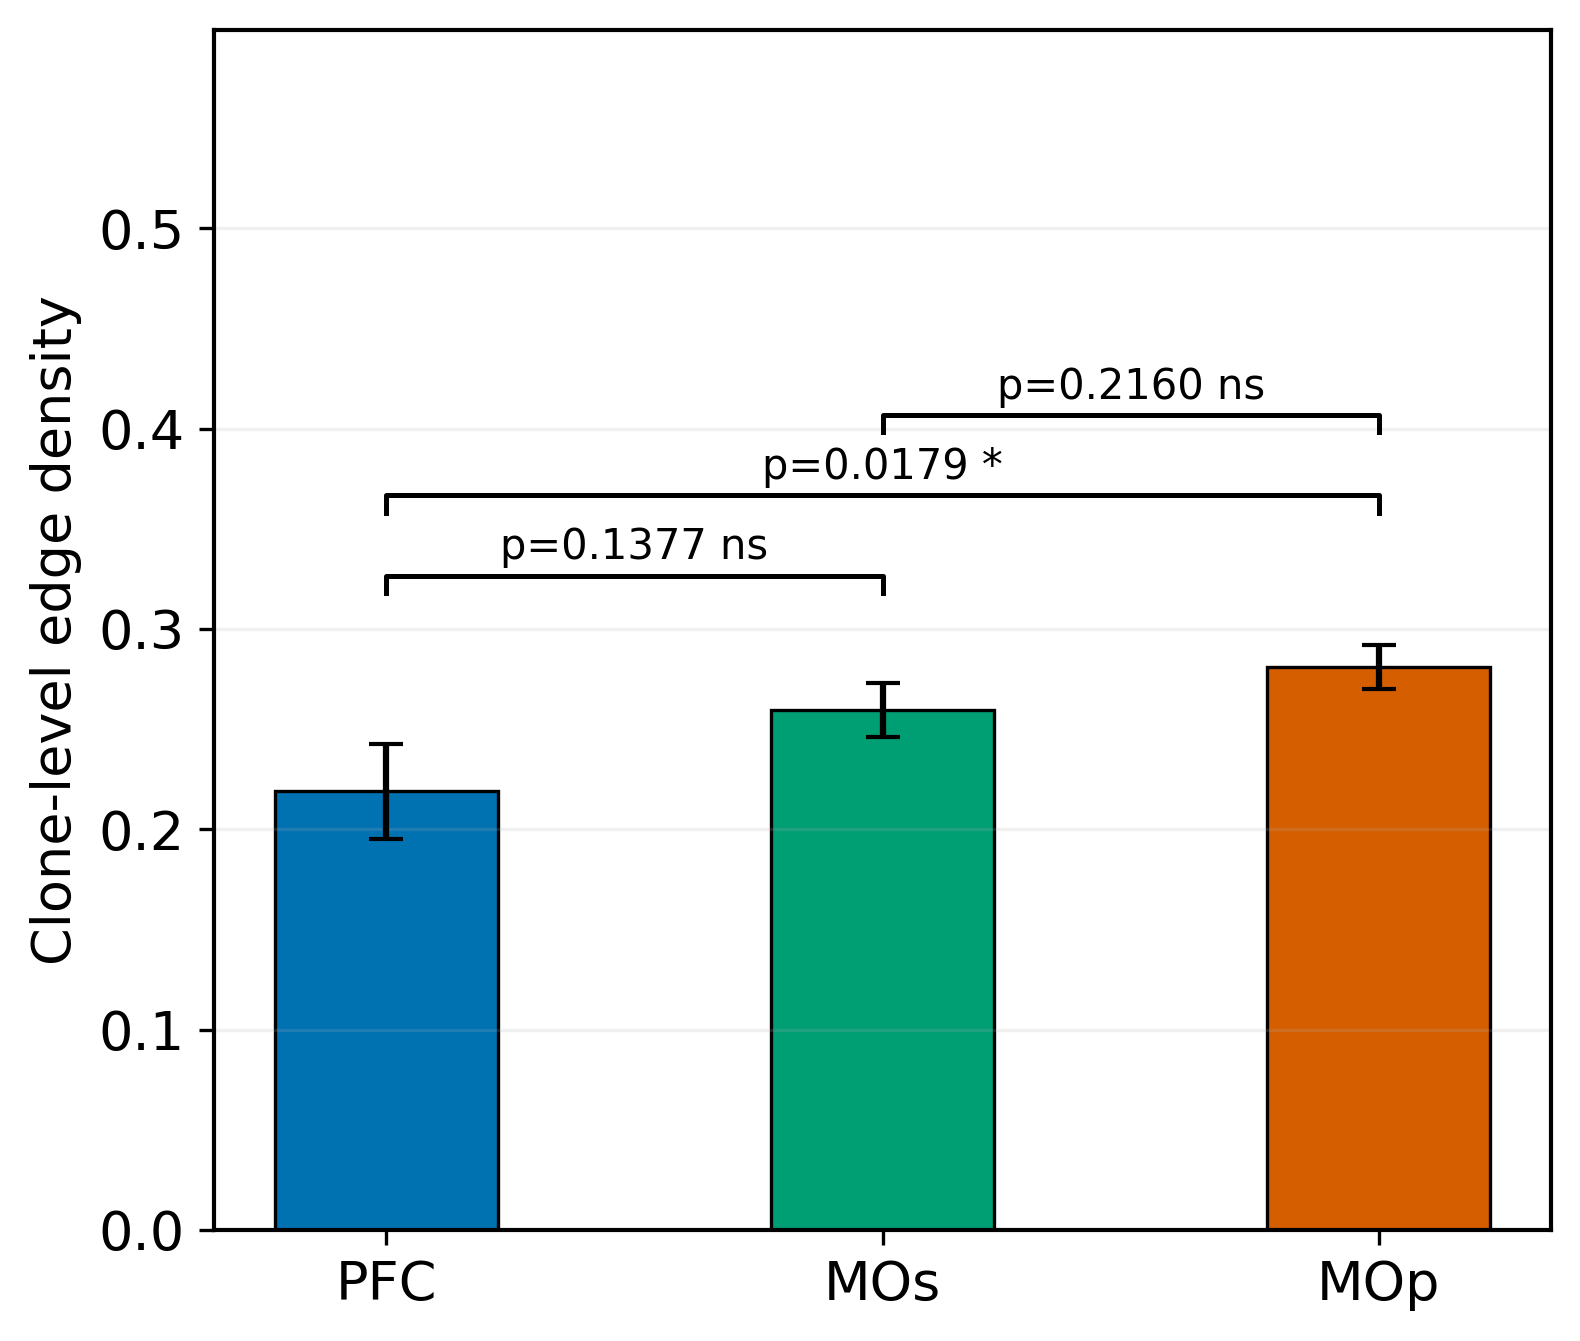

✅ Saved: clone_graph_edge_density.svg


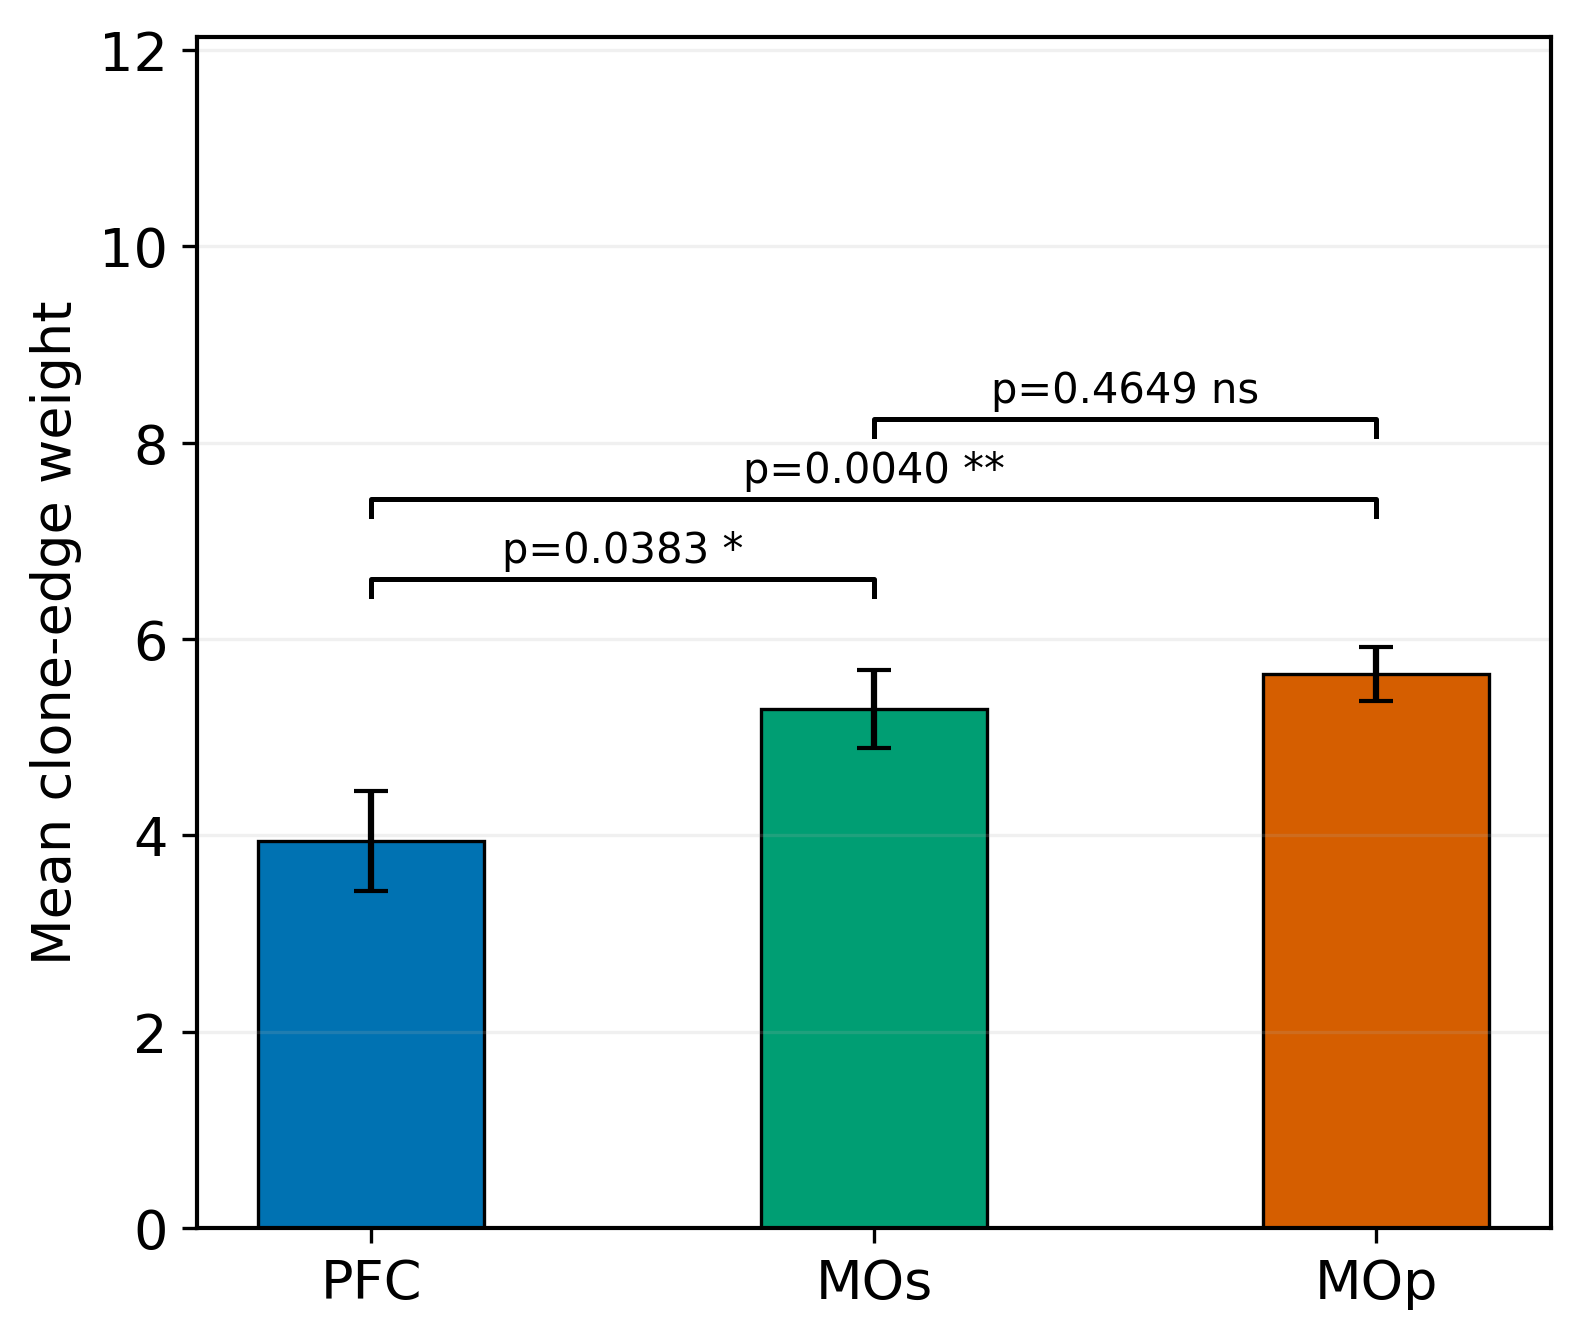

✅ Saved: clone_graph_mean_edge_weight.svg


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# ============================================================
# 输入：你需要已经有 sc, names, df
# 输出：
#   1) clone_graph_region_summary.csv
#   2) clone_graph_clone_node_metrics.csv
#   3) clone_graph_edge_density.svg
#   4) clone_graph_mean_edge_weight.svg
# ============================================================

# ===================== 0) 参数 =====================
edge_thr = 0.0
min_n = 3
regions = ["MOp", "MOs", "PFC"]

# 画图顺序（你要的）
plot_order = ["PFC", "MOs", "MOp"]

# 学术配色（Okabe-Ito）
colors = {"PFC": "#0072B2", "MOs": "#009E73", "MOp": "#D55E00"}

# 柱子更细一点
bar_w = 0.45

# ===================== 1) 字段识别 =====================
names = [str(x) for x in names]
name_to_idx = {nid: i for i, nid in enumerate(names)}

if "name" in df.columns:
    neuron_id_col = "name"
elif "Unnamed: 0" in df.columns:
    neuron_id_col = "Unnamed: 0"
else:
    raise ValueError("df 里找不到 neuron id 列（name / Unnamed: 0）")

if "clone" not in df.columns:
    raise ValueError("df 缺少 clone 列")

clone_region_col = None
for cand in ["Clone_region", "clone_region", "CLONE_REGION"]:
    if cand in df.columns:
        clone_region_col = cand
        break
if clone_region_col is None:
    raise ValueError("df 里找不到 Clone_region 列（Clone_region/clone_region/CLONE_REGION）")

df2 = df.copy()
df2[neuron_id_col] = df2[neuron_id_col].astype(str)
df2[clone_region_col] = df2[clone_region_col].astype(str)

def group3(r):
    r = str(r)
    if r.startswith("MOp"): return "MOp"
    if r.startswith("MOs"): return "MOs"
    return "PFC"

df2["group3"] = df2[clone_region_col].map(group3)

# ===================== 2) 对齐到 sc/names =====================
df2 = df2[df2[neuron_id_col].isin(name_to_idx)].copy()
df2["idx"] = df2[neuron_id_col].map(name_to_idx)

idx_to_clone = df2.set_index("idx")["clone"].to_dict()
idx_to_group = df2.set_index("idx")["group3"].to_dict()

# ===================== 3) 每脑区：构建 clone×clone 权重矩阵 W =====================
region_summary_rows = []
clone_node_rows = []

# 额外：给 t-test 用的样本
samples_edge_density = {}     # reg -> 0/1 向量，长度 C*(C-1)
samples_edge_weight  = {}     # reg -> 非零边权重向量

for reg in regions:
    idxs = np.array([i for i in range(len(names)) if (i in idx_to_group and idx_to_group[i] == reg)], dtype=int)
    if idxs.size < 3:
        print(f"[SKIP] {reg}: neuron 太少")
        continue

    sub_df = df2[df2["idx"].isin(idxs)]
    clone_to_idx = sub_df.groupby("clone")["idx"].apply(lambda x: np.array(sorted(set(x)), dtype=int)).to_dict()

    # 去掉太小 clone
    clone_to_idx = {cl: arr for cl, arr in clone_to_idx.items() if arr.size >= min_n}
    clones = sorted(clone_to_idx.keys(), key=lambda x: str(x))
    C = len(clones)
    if C < 2:
        print(f"[SKIP] {reg}: clone 太少（<2）")
        continue

    use_neurons = np.concatenate([clone_to_idx[cl] for cl in clones])
    use_neurons = np.array(sorted(set(use_neurons)), dtype=int)

    clone_id_map = {cl: ci for ci, cl in enumerate(clones)}
    labels = np.empty(use_neurons.size, dtype=int)
    for k, old_idx in enumerate(use_neurons):
        labels[k] = clone_id_map[idx_to_clone[old_idx]]

    A = sc[np.ix_(use_neurons, use_neurons)]
    B = (A > edge_thr)
    np.fill_diagonal(B, False)

    src, dst = np.where(B)
    if src.size == 0:
        print(f"[SKIP] {reg}: 没有边（thr={edge_thr}）")
        continue

    src_c = labels[src]
    dst_c = labels[dst]
    flat = src_c * C + dst_c
    W = np.bincount(flat, minlength=C*C).reshape(C, C).astype(np.int64)
    np.fill_diagonal(W, 0)

    # ---------- 图级指标 ----------
    E_nz = int(np.count_nonzero(W))
    denomE = C * (C - 1)
    edge_density = E_nz / denomE if denomE > 0 else np.nan
    mean_edge_weight = float(W[W > 0].mean()) if E_nz > 0 else np.nan

    region_summary_rows.append({
        "region": reg,
        "n_clones": C,
        "n_edges_nonzero": E_nz,
        "edge_density": edge_density,
        "mean_edge_weight_over_nonzero": mean_edge_weight,
        "edge_thr": edge_thr,
        "min_n": min_n,
    })

    # ---------- t-test 用样本 ----------
    # edge_density: 所有 i!=j 的 0/1（是否存在边）
    mask_off = ~np.eye(C, dtype=bool)
    samples_edge_density[reg] = (W[mask_off] > 0).astype(float)

    # mean_edge_weight: 非零边权重
    samples_edge_weight[reg] = W[W > 0].astype(float)

    # ---------- 节点级指标 ----------
    out_deg = (W > 0).sum(axis=1)
    in_deg  = (W > 0).sum(axis=0)
    out_str = W.sum(axis=1)
    in_str  = W.sum(axis=0)

    p_in = []
    n_neuron = []
    for cl in clones:
        n = int(clone_to_idx[cl].size)
        n_neuron.append(n)
        block = sc[np.ix_(clone_to_idx[cl], clone_to_idx[cl])]
        bb = (block > edge_thr)
        np.fill_diagonal(bb, False)
        e_in = int(np.count_nonzero(bb))
        p_in.append(e_in / (n*(n-1)) if n > 1 else 0.0)

    for i, cl in enumerate(clones):
        clone_node_rows.append({
            "region": reg,
            "clone": cl,
            "n_neuron": int(n_neuron[i]),
            "p_in": float(p_in[i]),
            "out_degree": int(out_deg[i]),
            "in_degree": int(in_deg[i]),
            "out_strength": int(out_str[i]),
            "in_strength": int(in_str[i]),
        })

    print(f"[OK] {reg}: clones={C}, edge_density={edge_density:.4f}, mean_w={mean_edge_weight:.2f}")

region_summary_df = pd.DataFrame(region_summary_rows)
clone_node_df = pd.DataFrame(clone_node_rows)

region_summary_df.to_csv("clone_graph_region_summary.csv", index=False)
clone_node_df.to_csv("clone_graph_clone_node_metrics.csv", index=False)
print("✅ Saved: clone_graph_region_summary.csv")
print("✅ Saved: clone_graph_clone_node_metrics.csv")

# ===================== 4) 画柱状图 + SEM + Welch t-test =====================
def sem(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size < 2:
        return np.nan
    return x.std(ddof=1) / np.sqrt(x.size)

def star(p):
    if not np.isfinite(p): return "NA"
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def plot_bar(metric_name, samples_dict, out_svg):
    # 按你要的顺序取
    regs = [r for r in plot_order if r in samples_dict]
    if len(regs) < 2:
        print(f"[SKIP] {metric_name}: 可用脑区不足 2 个")
        return

    means = [np.nanmean(samples_dict[r]) if np.isfinite(samples_dict[r]).any() else np.nan for r in regs]
    errs  = [sem(samples_dict[r]) for r in regs]

    x = np.arange(len(regs), dtype=float)

    fig, ax = plt.subplots(figsize=(5.4, 4.6))
    ax.bar(x, means, yerr=errs, capsize=4, width=bar_w,
           color=[colors[r] for r in regs], edgecolor="black", linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(regs, fontsize=13)
    ax.tick_params(axis="y", labelsize=13)
    ax.set_ylabel(metric_name, fontsize=13)

    # Welch 两两 t-test（括号全黑）
    pairs = []
    for i in range(len(regs)):
        for j in range(i+1, len(regs)):
            pairs.append((i, j))

    # y 上方留空间
    y0 = np.nanmax(np.array(means) + np.array(errs, float))
    y0 = 0.0 if not np.isfinite(y0) else y0
    pad = (y0 * 0.25 + 1e-6)
    ax.set_ylim(0, y0 + pad * (len(pairs) + 1.2))

    y_base = y0 + pad * 0.35
    y_step = pad * 0.55
    h = pad * 0.12

    for k, (i, j) in enumerate(pairs):
        a = np.asarray(samples_dict[regs[i]], float); a = a[np.isfinite(a)]
        b = np.asarray(samples_dict[regs[j]], float); b = b[np.isfinite(b)]
        p = np.nan if (a.size < 2 or b.size < 2) else float(ttest_ind(a, b, equal_var=False).pvalue)

        y = y_base + k * y_step
        ax.plot([x[i], x[i], x[j], x[j]], [y, y + h, y + h, y], color="black", lw=1.2)
        ax.text((x[i] + x[j]) / 2, y + h + pad*0.05, f"p={p:.4f} {star(p)}" if np.isfinite(p) else "p=NA NA",
                ha="center", va="bottom", fontsize=10, color="black")

    ax.grid(axis="y", alpha=0.18)
    fig.tight_layout()
    fig.savefig(out_svg, format="svg", bbox_inches="tight", transparent=True)
    plt.show()
    print("✅ Saved:", out_svg)

# edge_density（0/1 样本）
plot_bar("Clone-level edge density", samples_edge_density, "clone_graph_edge_density.svg")

# mean_edge_weight（非零权重样本）
plot_bar("Mean clone-edge weight", samples_edge_weight, "clone_graph_mean_edge_weight.svg")

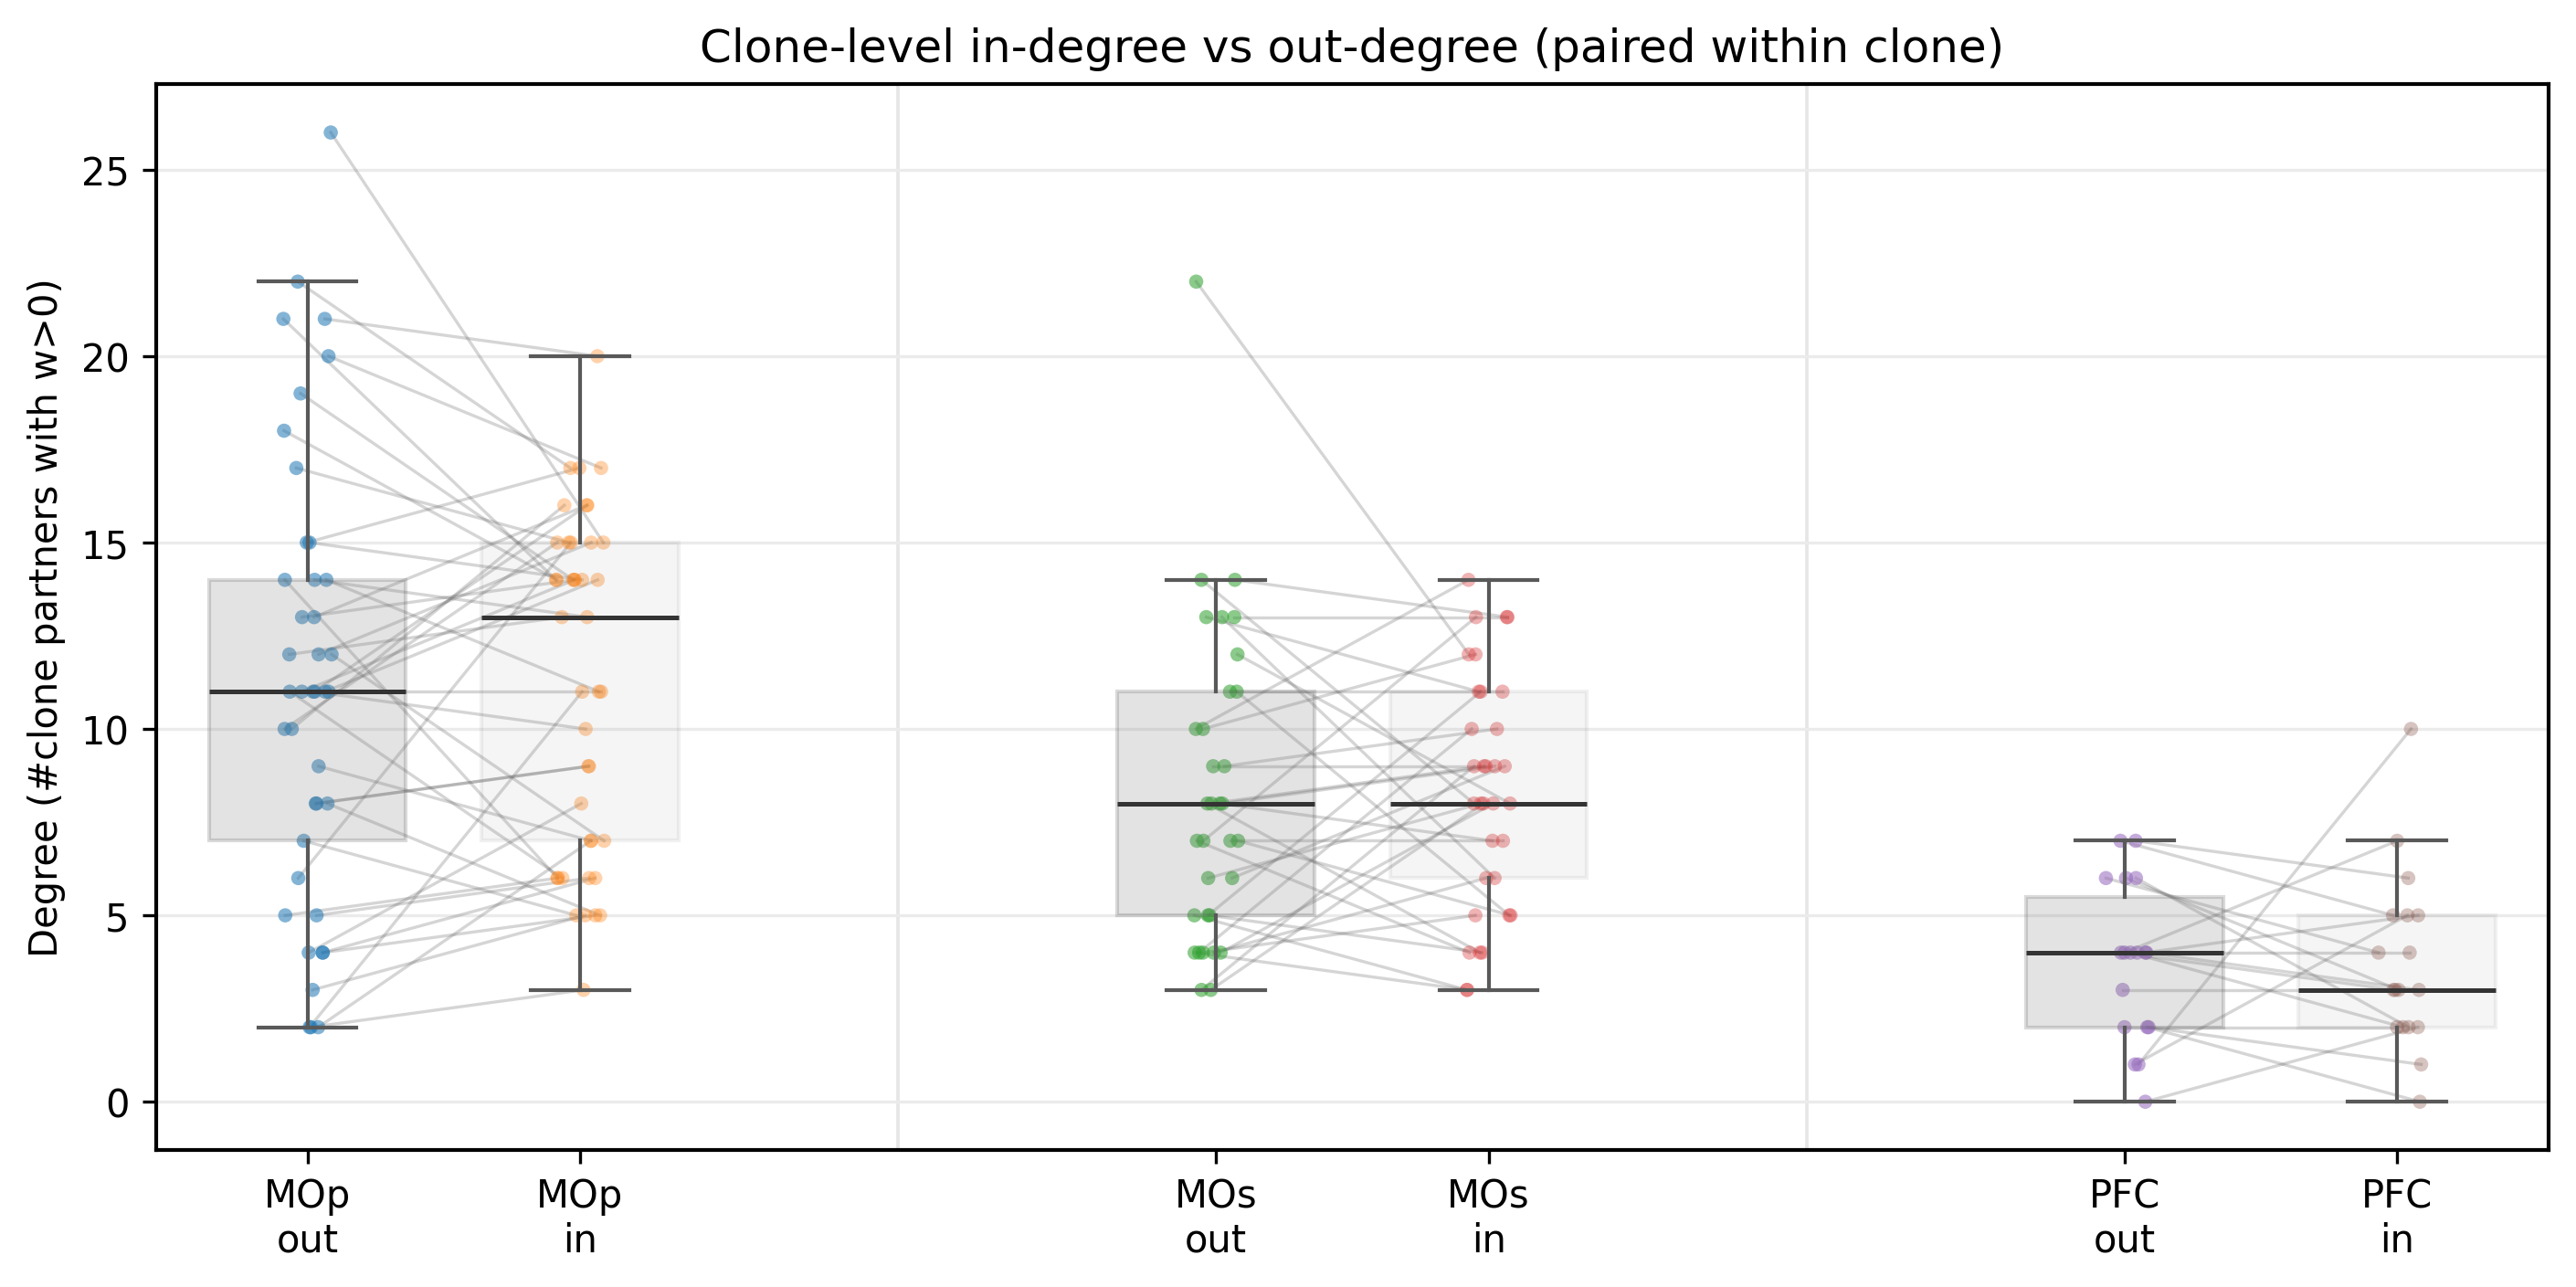

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# ====== 只画一个图：每个脑区两组箱线(out vs in) + 每个clone配对连线 ======
order = ["MOp", "MOs", "PFC"]
dfp = clone_node_df[clone_node_df["region"].isin(order)].copy()

plt.figure(figsize=(9.5, 4.8))
ax = plt.gca()

pos_out = np.arange(len(order)) * 3.0 + 1.0
pos_in  = pos_out + 0.9

box_data = []
positions = []
labels = []
alphas = []   # 每个箱子的透明度（out/in 有差异）

# ---- 统一风格参数（你主要想改的都在这）----
line_color = "0.35"   # 连线统一颜色（灰）
line_alpha = 0.25
line_lw = 0.8

out_alpha = 0.22      # out 箱子透明度
in_alpha  = 0.08      # in  箱子透明度（更淡）
out_point_alpha = 0.55
in_point_alpha  = 0.35
pt_size = 14

rng = np.random.default_rng(0)

for i, reg in enumerate(order):
    sub = dfp[dfp["region"] == reg][["clone", "out_degree", "in_degree"]].dropna()
    if sub.empty:
        continue

    outv = sub["out_degree"].to_numpy()
    inv  = sub["in_degree"].to_numpy()

    # 箱线数据
    box_data += [outv, inv]
    positions += [pos_out[i], pos_in[i]]
    labels += [f"{reg}\nout", f"{reg}\nin"]
    alphas += [out_alpha, in_alpha]

    # 同一个 clone 配对连线 + 点（线颜色统一）
    jitter = rng.uniform(-0.08, 0.08, size=len(sub))
    x1 = np.full(len(sub), pos_out[i]) + jitter
    x2 = np.full(len(sub), pos_in[i])  + jitter

    for xx1, yy1, xx2, yy2 in zip(x1, outv, x2, inv):
        ax.plot([xx1, xx2], [yy1, yy2], color=line_color, alpha=line_alpha, linewidth=line_lw, zorder=1)

    ax.scatter(x1, outv, s=pt_size, alpha=out_point_alpha, edgecolors="none", zorder=2)
    ax.scatter(x2, inv,  s=pt_size, alpha=in_point_alpha,  edgecolors="none", zorder=2)

# -------- 箱线图（箱子透明、边线统一）--------
bp = ax.boxplot(
    box_data,
    positions=positions,
    widths=0.65,
    showfliers=False,
    patch_artist=True,
    medianprops=dict(color="0.2", linewidth=1.2),
    whiskerprops=dict(color="0.35", linewidth=1.0),
    capprops=dict(color="0.35", linewidth=1.0),
    boxprops=dict(edgecolor="0.35", linewidth=1.0),
)

# 每个箱子设置透明度（out/in 有差异），颜色保持统一（不指定花色）
for patch, a in zip(bp["boxes"], alphas):
    patch.set_facecolor("0.5")   # 统一灰（你也可以换成 0.6/0.7）
    patch.set_alpha(a)

# -------- 分组分隔线（更轻、更细）--------
for i in range(len(order) - 1):
    ax.axvline((pos_in[i] + pos_out[i+1]) / 2, color="0.90", linewidth=0.9, zorder=0)

# -------- 轴与标题：更干净 --------
ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_ylabel("Degree (#clone partners with w>0)")
ax.set_title("Clone-level in-degree vs out-degree (paired within clone)")

# 轻网格（可选）
ax.grid(axis="y", color="0.92", linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


=== 脑区汇总（来自 Metadata_PFC_MOp.csv） ===
  region  n_clones  n_neurons  clone_size_mean  clone_size_std  \
0    MOp        41        333         8.121951        2.325888   
1    MOs        33        269         8.151515        2.346822   
2    PFC        18        149         8.277778        2.080881   

   clone_size_median  
0                7.0  
1                7.0  
2                8.0  

✅ 读取到 sparsity 表：clone_motif_layer_all_in_one_2-5um_noZ_withCn3.csv（用于画稀疏度对比）


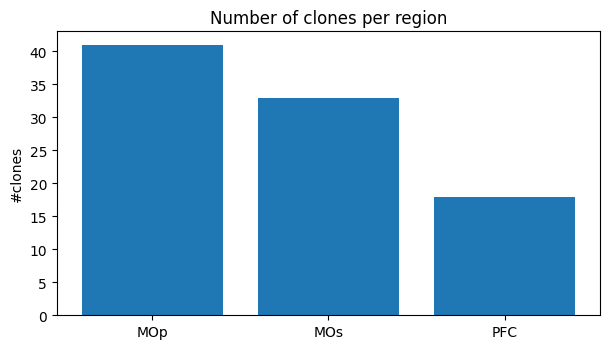

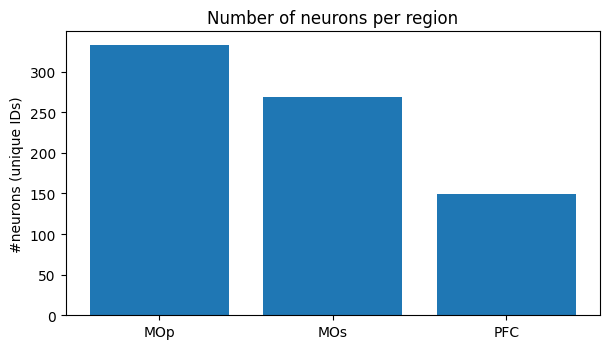

/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_52936/826261673.py:143: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)


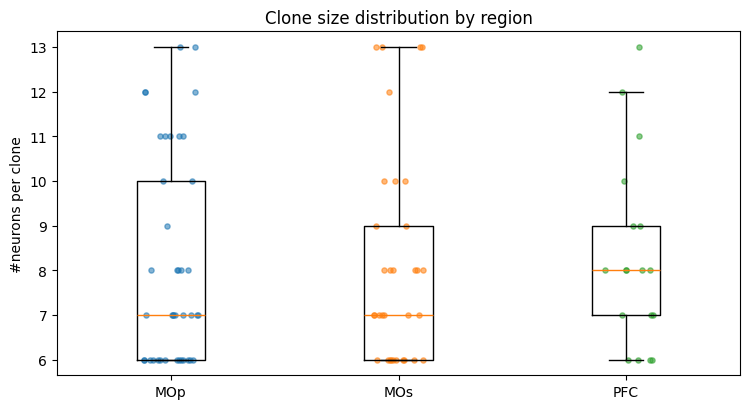


=== 稀疏度（来自你之前算过的表）=== 
  region  n_clones_with_sparsity      mean       std
0    MOp                      41  0.317268  0.169586
1    MOs                      33  0.395988  0.219505
2    PFC                      18  0.316981  0.223684


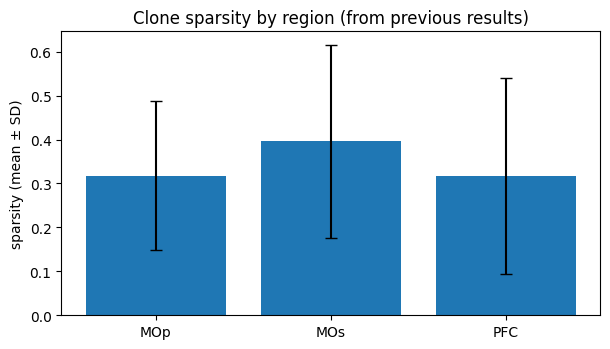

In [49]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0) 路径（按你自己的文件名改）
# =========================
csv_path = "Metadata_PFC_MOp.csv"

# 你“之前算过”的 clone 级结果表（含 clone + sparsity）
# 如果没有这个文件，脚本会自动跳过稀疏度图
sparsity_csv = "clone_motif_layer_all_in_one_2-5um_noZ_withCn3.csv"

# =========================
# 1) 读 clone 元数据
# =========================
df = pd.read_csv(csv_path)

# neuron id 列
if "name" in df.columns:
    neuron_id_col = "name"
elif "Unnamed: 0" in df.columns:
    neuron_id_col = "Unnamed: 0"
else:
    raise ValueError("CSV 里找不到 neuron id 列（name / Unnamed: 0）")

# clone 列
if "clone" not in df.columns:
    raise ValueError("CSV 缺少 clone 列")

# Clone_region 列（大小写兼容）
clone_region_col = None
for cand in ["Clone_region", "clone_region", "CLONE_REGION"]:
    if cand in df.columns:
        clone_region_col = cand
        break
if clone_region_col is None:
    raise ValueError("CSV 缺少 Clone_region 列（Clone_region/clone_region/CLONE_REGION）")

df[neuron_id_col] = df[neuron_id_col].astype(str)
df["clone"] = df["clone"].astype(str)
df[clone_region_col] = df[clone_region_col].astype(str)

# =========================
# 2) 三大脑区分组：MOp / MOs / 其他=PFC
# =========================
def group3(r):
    r = str(r)
    if r.startswith("MOp"):
        return "MOp"
    if r.startswith("MOs"):
        return "MOs"
    return "PFC"

df["region3"] = df[clone_region_col].map(group3)

# =========================
# 3) clone 粒度：每个 clone 的神经元数、所属脑区（投票）
# =========================
# 每个 clone 的脑区（clone 内 region3 多数票；一般都一致）
clone_region = (df.groupby("clone")["region3"]
                .agg(lambda x: x.value_counts().index[0])
                .rename("region3"))

# 每个 clone 的神经元数（按 neuron_id 去重更稳）
clone_n_neuron = (df.groupby("clone")[neuron_id_col]
                  .nunique()
                  .rename("n_neuron"))

clone_table = pd.concat([clone_region, clone_n_neuron], axis=1).reset_index()
# clone_table: clone / region3 / n_neuron

# =========================
# 4) 脑区级汇总：clone数、神经元数、clone大小分布统计
# =========================
order = ["MOp", "MOs", "PFC"]

region_summary = []
for r in order:
    sub_cl = clone_table[clone_table["region3"] == r]
    sub_neuron = df[df["region3"] == r][neuron_id_col].nunique()

    region_summary.append({
        "region": r,
        "n_clones": int(sub_cl["clone"].nunique()),
        "n_neurons": int(sub_neuron),
        "clone_size_mean": float(sub_cl["n_neuron"].mean()) if len(sub_cl) else np.nan,
        "clone_size_std": float(sub_cl["n_neuron"].std(ddof=1)) if len(sub_cl) > 1 else 0.0,
        "clone_size_median": float(sub_cl["n_neuron"].median()) if len(sub_cl) else np.nan,
    })

region_summary_df = pd.DataFrame(region_summary)
print("\n=== 脑区汇总（来自 Metadata_PFC_MOp.csv） ===")
print(region_summary_df)

# =========================
# 5) （可选）读入“之前算过”的 sparsity，并按脑区做均值/方差
#    需要 sparsity_csv 里至少有：clone, sparsity
# =========================
sparsity_df = None
if os.path.exists(sparsity_csv):
    tmp = pd.read_csv(sparsity_csv)
    if ("clone" in tmp.columns) and ("sparsity" in tmp.columns):
        sparsity_df = tmp[["clone", "sparsity"]].copy()
        # 合并脑区
        sparsity_df = sparsity_df.merge(clone_table[["clone", "region3"]], on="clone", how="left")
        print(f"\n✅ 读取到 sparsity 表：{sparsity_csv}（用于画稀疏度对比）")
    else:
        print(f"\n⚠️ {sparsity_csv} 找到了，但缺少 clone/sparsity 列，跳过稀疏度图")
        sparsity_df = None
else:
    print(f"\n⚠️ 未找到 {sparsity_csv}，跳过稀疏度图（你说的“之前算过”如果在别的文件，改 sparsity_csv）")

# =========================
# 6) 画图
# =========================
x = np.arange(len(order))

# ---- 图1：clone 数（柱状）----
plt.figure(figsize=(6.2, 3.6))
vals = region_summary_df.set_index("region").loc[order, "n_clones"].to_numpy()
plt.bar(x, vals)
plt.xticks(x, order)
plt.ylabel("#clones")
plt.title("Number of clones per region")
plt.tight_layout()
plt.show()

# ---- 图2：neuron 数（柱状）----
plt.figure(figsize=(6.2, 3.6))
vals = region_summary_df.set_index("region").loc[order, "n_neurons"].to_numpy()
plt.bar(x, vals)
plt.xticks(x, order)
plt.ylabel("#neurons (unique IDs)")
plt.title("Number of neurons per region")
plt.tight_layout()
plt.show()

# ---- 图3：clone 神经元数分布（箱线 + 散点）----
plt.figure(figsize=(7.6, 4.2))
data = [clone_table.loc[clone_table["region3"] == r, "n_neuron"].to_numpy() for r in order]
plt.boxplot(data, labels=order, showfliers=False)

rng = np.random.default_rng(0)
for i, r in enumerate(order, start=1):
    y = clone_table.loc[clone_table["region3"] == r, "n_neuron"].to_numpy()
    xj = i + rng.uniform(-0.12, 0.12, size=len(y))
    plt.scatter(xj, y, s=14, alpha=0.55)

plt.ylabel("#neurons per clone")
plt.title("Clone size distribution by region")
plt.tight_layout()
plt.show()

# ---- 图4：稀疏度对比（如果读到了 sparsity_df）----
if sparsity_df is not None and len(sparsity_df):
    # 每脑区：均值±标准差（只统计有 sparsity 的 clone）
    stats = []
    for r in order:
        v = sparsity_df.loc[sparsity_df["region3"] == r, "sparsity"].dropna().to_numpy()
        stats.append({
            "region": r,
            "n_clones_with_sparsity": int(v.size),
            "mean": float(v.mean()) if v.size else np.nan,
            "std": float(v.std(ddof=1)) if v.size > 1 else 0.0,
        })
    stats_df = pd.DataFrame(stats)
    print("\n=== 稀疏度（来自你之前算过的表）=== ")
    print(stats_df)

    means = stats_df.set_index("region").loc[order, "mean"].to_numpy()
    stds  = stats_df.set_index("region").loc[order, "std"].to_numpy()

    plt.figure(figsize=(6.2, 3.6))
    plt.bar(x, means, yerr=stds, capsize=4)
    plt.xticks(x, order)
    plt.ylabel("sparsity (mean ± SD)")
    plt.title("Clone sparsity by region (from previous results)")
    plt.tight_layout()
    plt.show()

In [43]:
# 做一份反向边，用来配对
rev = edges_df.rename(columns={"src":"dst","dst":"src","w":"w_rev","p":"p_rev","logw":"logw_rev"})
pair = edges_df.merge(rev[["src","dst","w_rev","p_rev"]], on=["src","dst"], how="left")
pair["w_rev"] = pair["w_rev"].fillna(0.0)
pair["p_rev"] = pair["p_rev"].fillna(0.0)

pair["recip_w"] = 2*np.minimum(pair["w"], pair["w_rev"]) / (pair["w"] + pair["w_rev"] + eps)
pair["asym_w"]  = (pair["w"] - pair["w_rev"]) / (pair["w"] + pair["w_rev"] + eps)

print(pair[["src","dst","w","w_rev","recip_w","asym_w"]].head())

            src           dst  w  w_rev   recip_w    asym_w
0  ACA-062301-1  ACA-070301-2  1    6.0  0.285714 -0.714286
1  ACA-062301-1  ACA-230026-1  2    1.0  0.666667  0.333333
2  ACA-062301-1  MOs-221411-1  1    0.0  0.000000  1.000000
3  ACA-062301-1  MOs-232965-2  8    0.0  0.000000  1.000000
4  ACA-062301-1  MOs-240013-1  2    0.0  0.000000  1.000000
